In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
from scipy.stats.contingency import association
# from scipy.stats import ranksums, iqr
import pingouin as pg
import warnings
# import scorecardpy as sc
import workflow_utils.visualization as viz
import workflow_utils.stats as stats
from optbinning import OptimalBinning

In [2]:
warnings.simplefilter(action='ignore', category=FutureWarning)
pd.options.display.float_format = '{:.3f}'.format

In [3]:
accepted = pd.read_csv('data/accepted.csv')
accepted.head()

C:\Users\ivan\AppData\Local\Temp\ipykernel_27368\2360842760.py:1: DtypeWarning: Columns (0,19,49,59,118,129,130,131,134,135,136,139,145,146,147) have mixed types. Specify dtype option on import or set low_memory=False.
  accepted = pd.read_csv('data/accepted.csv')


,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,...,hardship_payoff_balance_amount,hardship_last_payment_amount,disbursement_method,debt_settlement_flag,debt_settlement_flag_date,settlement_status,settlement_date,settlement_amount,settlement_percentage,settlement_term
0,68407277,NaN,3600.000,3600.000,3600.000,36 months,13.990,123.030,C,C4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
1,68355089,NaN,24700.000,24700.000,24700.000,36 months,11.990,820.280,C,C1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
2,68341763,NaN,20000.000,20000.000,20000.000,60 months,10.780,432.660,B,B4,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
3,66310712,NaN,35000.000,35000.000,35000.000,60 months,14.850,829.900,C,C5,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN
4,68476807,NaN,10400.000,10400.000,10400.000,60 months,22.450,289.910,F,F1,...,NaN,NaN,Cash,N,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
accepted.shape

(2260701, 151)

Drop columns with > 30% missing or 99% values in a single value

In [5]:
percent_missing = accepted.isna().mean()


In [6]:
accepted = accepted.drop(columns=percent_missing[percent_missing > 0.3].index)

In [7]:
accepted.shape

(2260701, 93)

In [8]:
mode_proportions = accepted.apply(lambda x: x.value_counts(normalize=True).iloc[0])
mode_proportions

id                           0.000
loan_amnt                    0.083
funded_amnt                  0.083
funded_amnt_inv              0.079
term                         0.712
                              ... 
total_bc_limit               0.011
total_il_high_credit_limit   0.120
hardship_flag                1.000
disbursement_method          0.965
debt_settlement_flag         0.985
Length: 93, dtype: float64

In [9]:
accepted = accepted.drop(columns=mode_proportions[mode_proportions >= 0.95].index)
accepted.shape

(2260701, 80)

In [10]:
accepted.columns

Index(['id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'annual_inc', 'verification_status', 'issue_d',
       'loan_status', 'url', 'purpose', 'title', 'zip_code', 'addr_state',
       'dti', 'delinq_2yrs', 'earliest_cr_line', 'fico_range_low',
       'fico_range_high', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal',
       'revol_util', 'total_acc', 'initial_list_status', 'out_prncp',
       'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp',
       'total_rec_int', 'recoveries', 'collection_recovery_fee',
       'last_pymnt_d', 'last_pymnt_amnt', 'last_credit_pull_d',
       'last_fico_range_high', 'last_fico_range_low', 'application_type',
       'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_t

In [11]:
columns_todrop = ['id', 'sub_grade', 'url', 'title', 'emp_title', 'zip_code']
accepted = accepted.drop(columns=columns_todrop)

In [12]:
accepted.dtypes.unique()

array([dtype('float64'), dtype('O')], dtype=object)

In [13]:
datetime_columns = ["issue_d", "earliest_cr_line", "last_pymnt_d", "last_credit_pull_d"]
accepted[datetime_columns].head()

,issue_d,earliest_cr_line,last_pymnt_d,last_credit_pull_d
0,Dec-2015,Aug-2003,Jan-2019,Mar-2019
1,Dec-2015,Dec-1999,Jun-2016,Mar-2019
2,Dec-2015,Aug-2000,Jun-2017,Mar-2019
3,Dec-2015,Sep-2008,Feb-2019,Mar-2019
4,Dec-2015,Jun-1998,Jul-2016,Mar-2018


In [14]:
accepted[datetime_columns] = accepted[datetime_columns].apply(pd.to_datetime, format='%b-%Y')

In [15]:
accepted[datetime_columns].head()

,issue_d,earliest_cr_line,last_pymnt_d,last_credit_pull_d
0,2015-12-01,2003-08-01,2019-01-01,2019-03-01
1,2015-12-01,1999-12-01,2016-06-01,2019-03-01
2,2015-12-01,2000-08-01,2017-06-01,2019-03-01
3,2015-12-01,2008-09-01,2019-02-01,2019-03-01
4,2015-12-01,1998-06-01,2016-07-01,2018-03-01


The column of interest should be either num_accts_ever_120_pd or loan_status or delinq_2yrs or num_tl_90g_dpd_24m

In [16]:
accepted["loan_status"].unique()

array(['Fully Paid', 'Current', 'Charged Off', 'In Grace Period',
       'Late (31-120 days)', 'Late (16-30 days)', 'Default', nan,
       'Does not meet the credit policy. Status:Fully Paid',
       'Does not meet the credit policy. Status:Charged Off'],
      dtype=object)

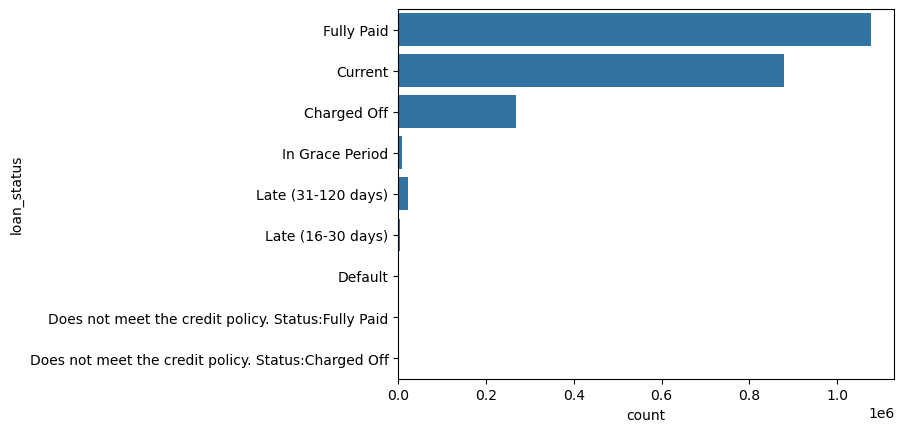

In [17]:
_ = sns.countplot(y="loan_status", data=accepted)

In [18]:
accepted = accepted[~accepted["loan_status"].isin(["Current", "In Grace Period", "Late (16-30 days)", "Does not meet the credit policy. Status:Fully Paid"])].dropna(subset=["loan_status"])
accepted["default"] = accepted["loan_status"].map({
    "Fully Paid": 0,
    "Charged Off": 1,
    "Late (31-120 days)": 1,
    "Default": 1,
    "Does not meet the credit policy. Status:Charged Off": 1
})

In [19]:
accepted["num_accts_ever_120_pd"].unique()

array([ 2.,  0.,  1.,  4.,  5.,  3.,  7.,  8.,  6., 17., 12., 13., 11.,
        9., 26., 10., 14., 16., 18., 25., 32., 23., 15., 20., 24., 30.,
       27., 21., 22., 19., 31., 29., 39., 28., 35., 34., 38., 33., nan,
       51.])

In [20]:
bad_closed = accepted[accepted["default"] == 1]
bad_closed["num_accts_ever_120_pd"].unique()

array([ 0.,  1.,  3.,  2.,  4.,  5., 26.,  6.,  7.,  8., 11., 10.,  9.,
       12., 15., 14., 20., 13., 21., 19., 17., 23., 18., 16., 22., 24.,
       34., 29., 30., 27., nan, 25., 32., 31., 33.])

There are defaults/charged offs with 0 accounts over 120 pd

In [21]:
accepted["delinq_2yrs"].unique()

array([ 0.,  1.,  2.,  3.,  4.,  6.,  5., 15.,  7.,  9., 10.,  8., 11.,
       13., 14., 12., 30., 18., 16., 17., 26., 20., 19., 22., 27., 39.,
       28., 25., 21., nan, 29., 24., 36.])

In [22]:
bad_closed["delinq_2yrs"].unique()

array([ 0.,  2.,  1.,  4.,  5.,  3.,  7.,  9.,  6., 11.,  8., 13., 14.,
       12., 10., 16., 18., 17., 15., 20., 19., 27., 25., 21., nan, 36.])

In [23]:
accepted["num_tl_90g_dpd_24m"].unique()

array([ 0.,  1.,  2.,  4., 12.,  7.,  3.,  8.,  5., 13., 11., 10.,  6.,
        9., 14., 30., 16., 15., 26., 22., 18., 39., 20., 17., 21., 25.,
       19., nan, 24., 36., 29.])

In [24]:
bad_closed["num_tl_90g_dpd_24m"].unique()

array([ 0.,  1.,  2.,  5.,  7.,  8., 11.,  3.,  4.,  6., 13.,  9., 10.,
       16., 12., 14., 26., 20., 15., 21., 19., 18., nan, 17., 36.])

Drop columns that would not be available for an application scorecard

In [25]:
accepted.columns

Index(['loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate',
       'installment', 'grade', 'emp_length', 'home_ownership', 'annual_inc',
       'verification_status', 'issue_d', 'loan_status', 'purpose',
       'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line',
       'fico_range_low', 'fico_range_high', 'inq_last_6mths', 'open_acc',
       'pub_rec', 'revol_bal', 'revol_util', 'total_acc',
       'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt',
       'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'recoveries',
       'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt',
       'last_credit_pull_d', 'last_fico_range_high', 'last_fico_range_low',
       'application_type', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim',
       'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util',
       'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op',
       'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc',

In [26]:
#columns_todrop = ["grade", "loan_status", "delinq_2yrs", "out_prncp", "out_prncp_inv", "total_pymnt", "total_pymnt_inv",
#                  "total_rec_prncp", "total_rec_int", "recoveries", "collection_recovery_fee", "last_pymnt_d", "last_pymnt_amnt",
#                  "tot_coll_amt", "tot_cur_bal", "avg_cur_bal", "bc_util", "num_accts_ever_120_pd", "num_tl_90g_dpd_24m"]

In [27]:
application_columns = ["loan_amnt", "funded_amnt", "funded_amnt_inv", "term", "int_rate", "installment", "grade",
                       "emp_length", "home_ownership", "annual_inc", "verification_status", "issue_d", "default",
                       "purpose", "addr_state", "dti", "earliest_cr_line", "fico_range_low", "fico_range_high",
                       "inq_last_6mths", "open_acc", "pub_rec", "revol_bal", "revol_util", "total_acc",
                       "initial_list_status"]
accepted = accepted[application_columns]

In [28]:
accepted.shape

(1367578, 26)

In [29]:
accepted.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1367578 entries, 0 to 2260697
Data columns (total 26 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   loan_amnt            1367578 non-null  float64       
 1   funded_amnt          1367578 non-null  float64       
 2   funded_amnt_inv      1367578 non-null  float64       
 3   term                 1367578 non-null  object        
 4   int_rate             1367578 non-null  float64       
 5   installment          1367578 non-null  float64       
 6   grade                1367578 non-null  object        
 7   emp_length           1287196 non-null  object        
 8   home_ownership       1367578 non-null  object        
 9   annual_inc           1367578 non-null  float64       
 10  verification_status  1367578 non-null  object        
 11  issue_d              1367578 non-null  datetime64[ns]
 12  default              1367578 non-null  int64         
 13  pu

In [30]:
accepted.describe()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,issue_d,default,dti,earliest_cr_line,fico_range_low,fico_range_high,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc
count,1367578.000,1367578.000,1367578.000,1367578.000,1367578.000,1367578.000,1367578,1367578.000,1367180.000,1367575,1367578.000,1367578.000,1367574.000,1367575.000,1367575.000,1367578.000,1366688.000,1367575.000
mean,14456.908,14448.475,14424.438,13.278,438.980,76256.047,2015-06-16 21:27:06.770247680,0.213,18.310,1999-03-17 05:28:23.237043584,696.116,700.116,0.657,11.593,0.216,16234.724,51.776,24.950
min,500.000,500.000,0.000,5.310,4.930,0.000,2007-06-01 00:00:00,0.000,-1.000,1934-04-01 00:00:00,615.000,619.000,0.000,0.000,0.000,0.000,0.000,1.000
25%,8000.000,8000.000,7925.000,9.750,249.050,45760.000,2014-07-01 00:00:00,0.000,11.800,1995-05-01 00:00:00,670.000,674.000,0.000,8.000,0.000,5931.000,33.400,16.000
50%,12000.000,12000.000,12000.000,12.740,375.430,65000.000,2015-08-01 00:00:00,0.000,17.630,2000-08-01 00:00:00,690.000,694.000,0.000,11.000,0.000,11122.000,52.100,23.000
75%,20000.000,20000.000,20000.000,16.020,581.618,90000.000,2016-07-01 00:00:00,0.000,24.080,2004-07-01 00:00:00,710.000,714.000,1.000,14.000,0.000,19736.000,70.700,32.000
max,40000.000,40000.000,40000.000,30.990,1719.830,10999200.000,2018-12-01 00:00:00,1.000,999.000,2015-10-01 00:00:00,845.000,850.000,33.000,90.000,86.000,2904836.000,892.300,176.000
std,8738.090,8734.279,8737.886,4.786,262.022,70309.493,NaN,0.409,11.316,NaN,31.816,31.816,0.945,5.482,0.604,22344.667,24.531,12.006


In [31]:
accepted.isna().sum()

loan_amnt                  0
funded_amnt                0
funded_amnt_inv            0
term                       0
int_rate                   0
installment                0
grade                      0
emp_length             80382
home_ownership             0
annual_inc                 0
verification_status        0
issue_d                    0
default                    0
purpose                    0
addr_state                 0
dti                      398
earliest_cr_line           3
fico_range_low             0
fico_range_high            0
inq_last_6mths             4
open_acc                   3
pub_rec                    3
revol_bal                  0
revol_util               890
total_acc                  3
initial_list_status        0
dtype: int64

Assumption about nulls:  
 - emp_length null means unemployed so 0
 - dti null means no debt so 0
 - revol_util null means no utilization so 0
 - inq_last_6mths null means no inquiries so 0
 - open_acc null means no open accounts so 0
 - pub_rec null means no records, so 0
 - total_acc null means no accounts, so 0

In [32]:
accepted.loc[:,"emp_length"] = accepted["emp_length"].fillna("0")
accepted.loc[:,"dti"] = accepted["dti"].fillna(0)
accepted.loc[:,"revol_util"] = accepted["revol_util"].fillna(0)
accepted.loc[:, "inq_last_6mths"] = accepted["inq_last_6mths"].fillna(0)
accepted.loc[:, "open_acc"] = accepted["open_acc"].fillna(0)
accepted.loc[:, "pub_rec"] = accepted["pub_rec"].fillna(0)
accepted.loc[:, "total_acc"] = accepted["total_acc"].fillna(0)

In [33]:
stats.kstests(accepted, "default")

,feature,statistic,pvalue
0,loan_amnt,0.084,0.000
1,funded_amnt,0.084,0.000
2,funded_amnt_inv,0.084,0.000
3,int_rate,0.265,0.000
4,installment,0.073,0.000
5,annual_inc,0.068,0.000
6,dti,0.111,0.000
7,fico_range_low,0.134,0.000
8,fico_range_high,0.134,0.000
9,inq_last_6mths,0.070,0.000


In [34]:
stats.pearson_chi2(accepted, "default")

,feature,statistic,pvalue
0,term,44727.489,0.000
1,grade,95209.381,0.000
2,emp_length,3139.242,0.000
3,home_ownership,7009.114,0.000
4,verification_status,10967.742,0.000
5,purpose,4351.962,0.000
6,addr_state,NaN,NaN
7,initial_list_status,451.394,0.000


<Axes: >

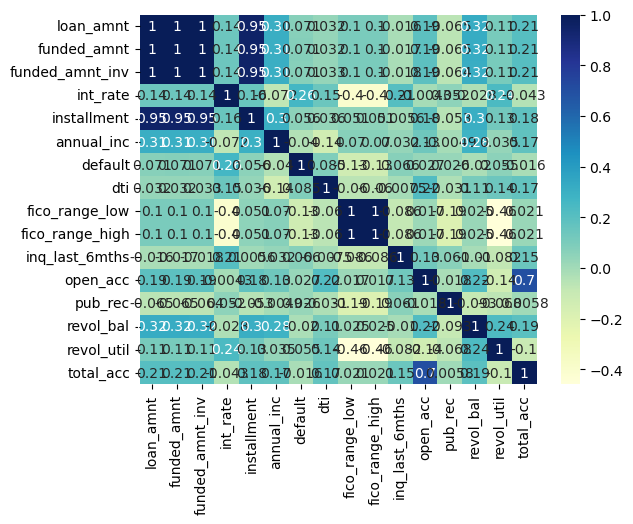

In [35]:
viz.correlation_heatmap(accepted)

Default

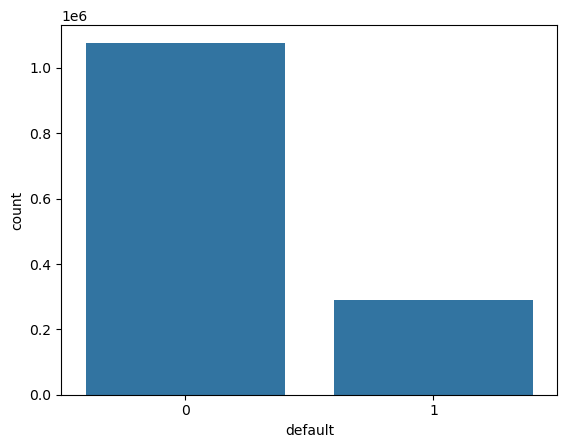

In [36]:
_ = sns.countplot(data=accepted, x="default")

In [37]:
accepted["default"].mean()

np.float64(0.2126584370324764)

loan_amnt

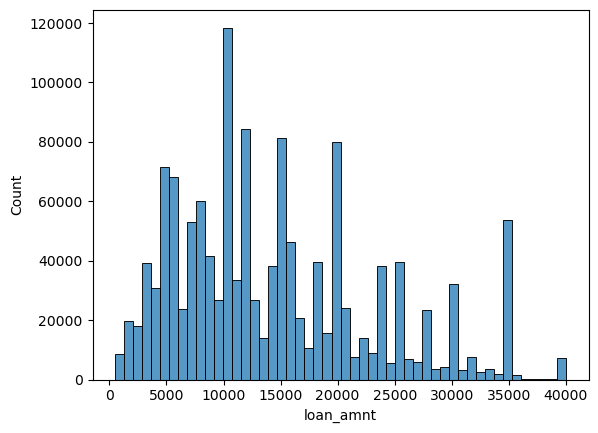

In [38]:
_ = sns.histplot(accepted["loan_amnt"], bins=50)

In [39]:
stats.kstests(accepted, "default", selected_columns=["loan_amnt"])

,feature,statistic,pvalue
0,loan_amnt,0.084,0.000


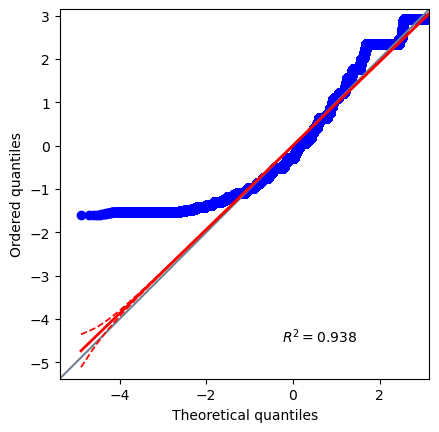

In [40]:
_ = pg.qqplot(accepted["loan_amnt"], dist='norm')

right skewed

In [41]:
optb = OptimalBinning(name="loan_amnt", dtype="numerical", solver="cp")
optb.fit(x=accepted["loan_amnt"], y=accepted["default"])
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 3512.50)",78831,0.058,66535,12296,0.156,0.379,0.007,0.001
1,"[3512.50, 7012.50)",227064,0.166,187858,39206,0.173,0.258,0.010,0.001
2,"[7012.50, 9012.50)",126163,0.092,103629,22534,0.179,0.217,0.004,0.001
3,"[9012.50, 10012.50)",130917,0.096,104553,26364,0.201,0.069,0.000,0.000
4,"[10012.50, 12012.50)",130453,0.095,102236,28217,0.216,-0.022,0.000,0.000
5,"[12012.50, 15012.50)",157672,0.115,122607,35065,0.222,-0.057,0.000,0.000
6,"[15012.50, 28012.50)",393859,0.288,299233,94626,0.240,-0.158,0.007,0.001
7,"[28012.50, inf)",122619,0.090,90100,32519,0.265,-0.290,0.008,0.001
8,Special,0,0.000,0,0,0.000,0.000,0.000,0.000
9,Missing,0,0.000,0,0,0.000,0.000,0.000,0.000


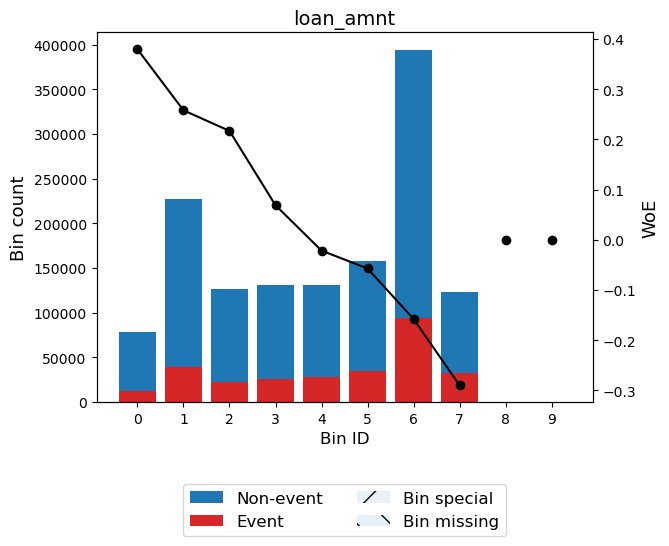

In [42]:
optb.binning_table.plot(metric="woe")

funded_amnt

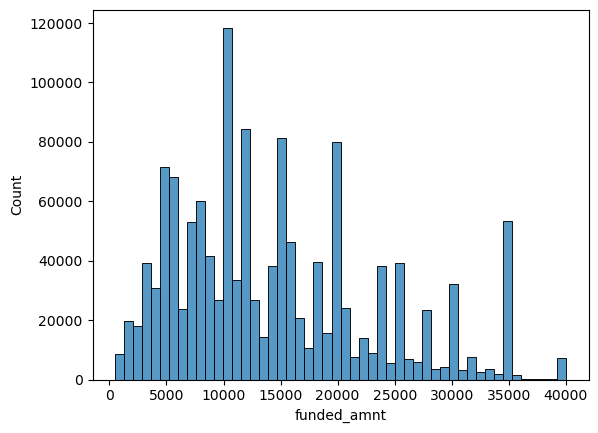

In [43]:
_ = sns.histplot(accepted["funded_amnt"], bins=50)

In [44]:
stats.kstests(accepted, "default", selected_columns=["funded_amnt"])

,feature,statistic,pvalue
0,funded_amnt,0.084,0.000


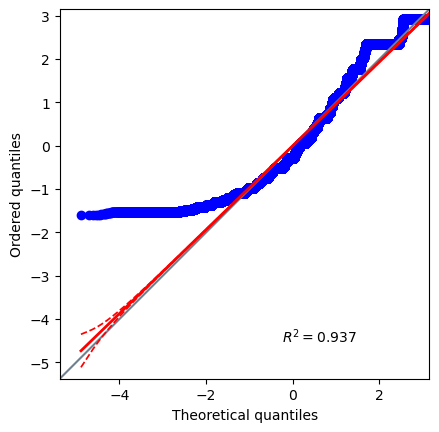

In [45]:
_ = pg.qqplot(accepted["funded_amnt"], dist='norm')

In [46]:
optb = OptimalBinning(name="funded_amnt", dtype="numerical", solver="cp")
optb.fit(x=accepted["funded_amnt"], y=accepted["default"])
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 3512.50)",78875,0.058,66568,12307,0.156,0.379,0.007,0.001
1,"[3512.50, 7012.50)",227257,0.166,188012,39245,0.173,0.258,0.010,0.001
2,"[7012.50, 9012.50)",126224,0.092,103690,22534,0.179,0.217,0.004,0.001
3,"[9012.50, 10012.50)",130919,0.096,104554,26365,0.201,0.069,0.000,0.000
4,"[10012.50, 12012.50)",130569,0.095,102317,28252,0.216,-0.022,0.000,0.000
5,"[12012.50, 15012.50)",157771,0.115,122694,35077,0.222,-0.057,0.000,0.000
6,"[15012.50, 28012.50)",393553,0.288,298970,94583,0.240,-0.158,0.008,0.001
7,"[28012.50, inf)",122410,0.090,89946,32464,0.265,-0.290,0.008,0.001
8,Special,0,0.000,0,0,0.000,0.000,0.000,0.000
9,Missing,0,0.000,0,0,0.000,0.000,0.000,0.000


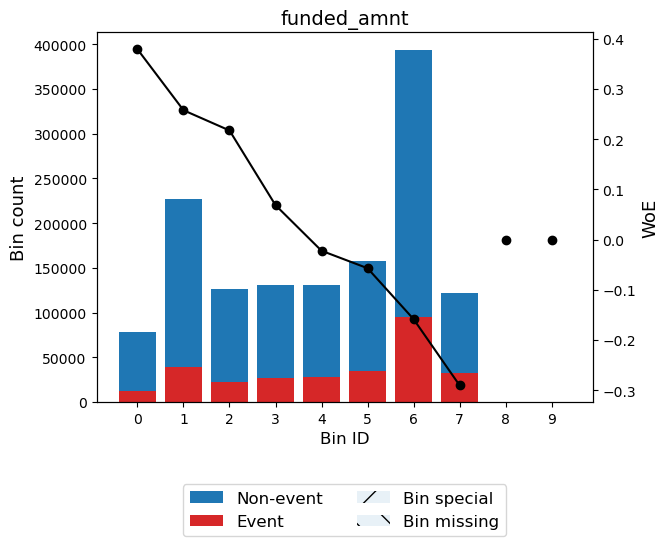

In [47]:
optb.binning_table.plot(metric="woe")

funded_amnt_inv

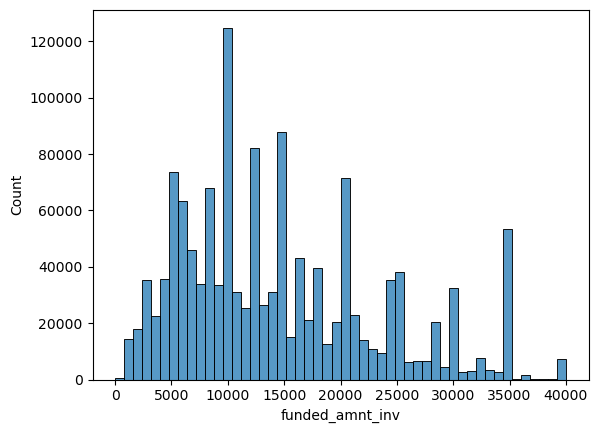

In [48]:
_ = sns.histplot(accepted["funded_amnt_inv"], bins=50)

In [49]:
stats.kstests(accepted, "default", selected_columns=["funded_amnt_inv"])

,feature,statistic,pvalue
0,funded_amnt_inv,0.084,0.000


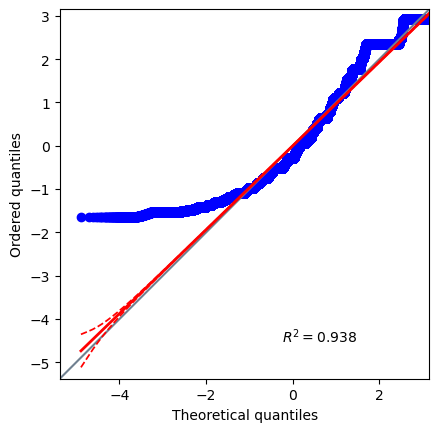

In [50]:
_ = pg.qqplot(accepted["funded_amnt_inv"], dist='norm')

term

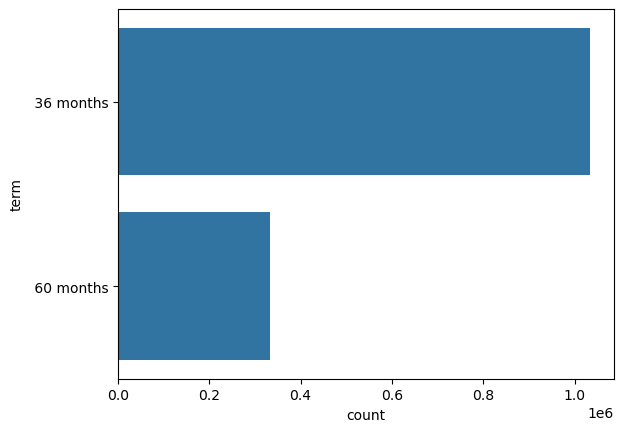

In [51]:
_ = sns.countplot(accepted["term"])

In [199]:
ct = pd.crosstab(accepted["term"], accepted["default"])
ct

default,0,1
term,,
36 months,857491,176400
60 months,219260,114427


In [53]:
pd.crosstab(accepted["term"], accepted["default"], normalize="all")

default,0,1
term,,
36 months,0.627,0.129
60 months,0.160,0.084


In [54]:
pd.crosstab(accepted["term"], accepted["default"], normalize="index")

default,0,1
term,,
36 months,0.829,0.171
60 months,0.657,0.343


In [55]:
stats.pearson_chi2(accepted, "default", selected_columns=["term"])

,feature,statistic,pvalue
0,term,44727.489,0.000


In [200]:
association(ct, method='cramer')

0.18084903715330292

In [56]:
optb = OptimalBinning(name="term", dtype="categorical", solver="cp")
optb.fit(x=accepted["term"], y=accepted["default"])
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,[ 36 months],1033891,0.756,857491,176400,0.171,0.272,0.052,0.006
1,[ 60 months],333687,0.244,219260,114427,0.343,-0.659,0.125,0.015
2,Special,0,0.000,0,0,0.000,0.000,0.000,0.000
3,Missing,0,0.000,0,0,0.000,0.000,0.000,0.000
Totals,,1367578,1.000,1076751,290827,0.213,,0.177,0.022


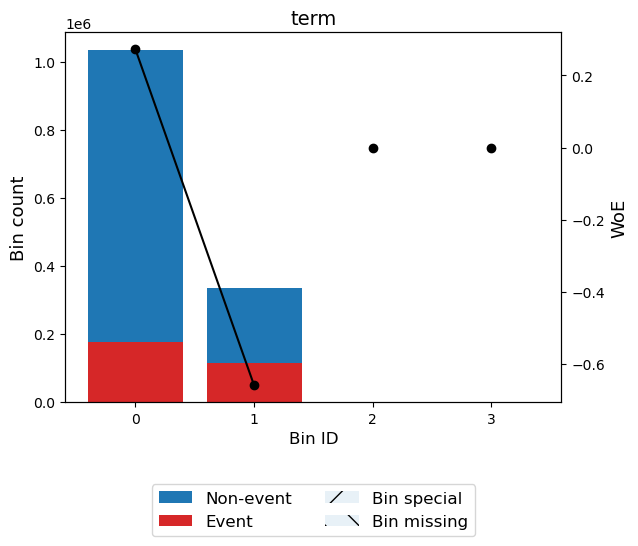

In [57]:
optb.binning_table.plot(metric="woe")

int_rate

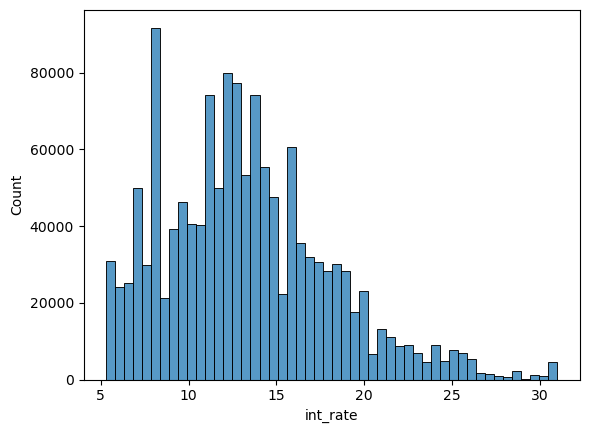

In [58]:
_ = sns.histplot(accepted["int_rate"], bins=50)

In [59]:
stats.kstests(accepted, "default", selected_columns=["int_rate"])

,feature,statistic,pvalue
0,int_rate,0.265,0.000


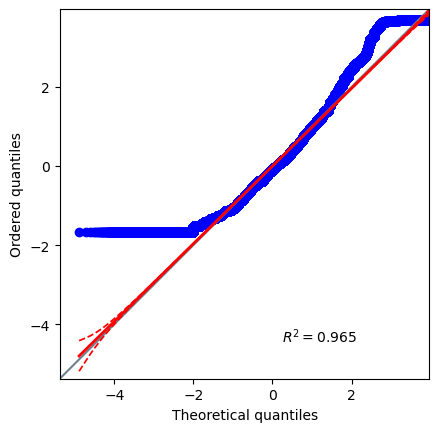

In [60]:
_ = pg.qqplot(accepted["int_rate"], dist='norm')

In [61]:
optb = OptimalBinning(name="int_rate", dtype="numerical", solver="cp")
optb.fit(x=accepted["int_rate"], y=accepted["default"])
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 6.90)",87156,0.064,83391,3765,0.043,1.789,0.115,0.013
1,"[6.90, 7.93)",110766,0.081,102572,8194,0.074,1.218,0.082,0.010
2,"[7.93, 9.73)",138335,0.101,122938,15397,0.111,0.769,0.047,0.006
3,"[9.73, 10.54)",76501,0.056,65447,11054,0.144,0.469,0.011,0.001
4,"[10.54, 11.15)",72754,0.053,61885,10869,0.149,0.430,0.009,0.001
5,"[11.15, 12.57)",157955,0.115,130517,27438,0.174,0.251,0.007,0.001
6,"[12.57, 13.36)",114034,0.083,90218,23816,0.209,0.023,0.000,0.000
7,"[13.36, 14.37)",121546,0.089,92936,28610,0.235,-0.131,0.002,0.000
8,"[14.37, 15.97)",134169,0.098,99793,34376,0.256,-0.243,0.006,0.001
9,"[15.97, 17.78)",123899,0.091,86553,37346,0.301,-0.468,0.022,0.003


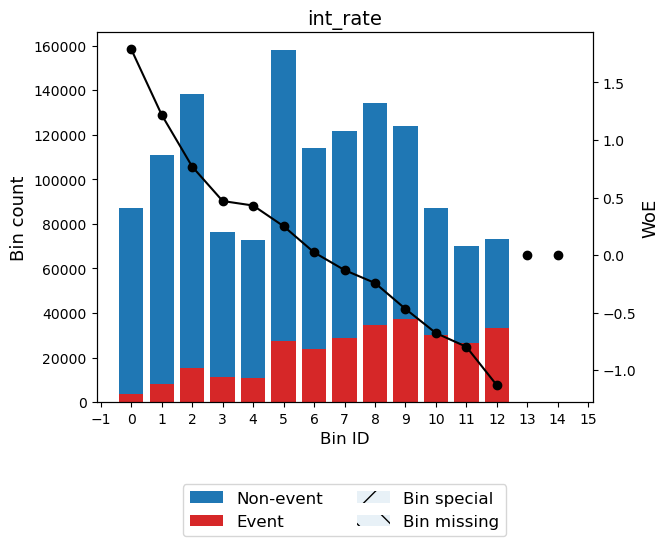

In [62]:
optb.binning_table.plot(metric="woe")

installment

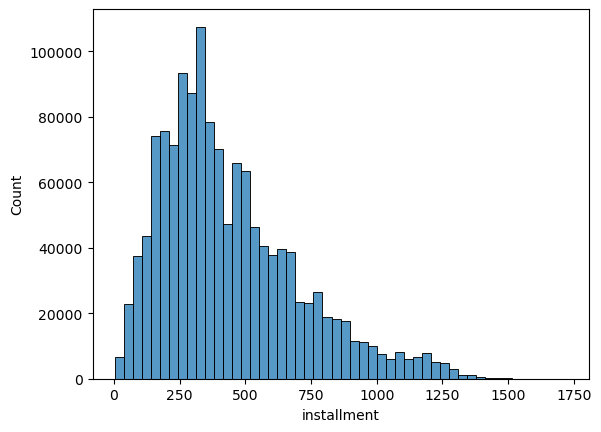

In [63]:
_ = sns.histplot(accepted["installment"], bins=50)

In [64]:
stats.kstests(accepted, "default", selected_columns=["installment"])

,feature,statistic,pvalue
0,installment,0.073,0.000


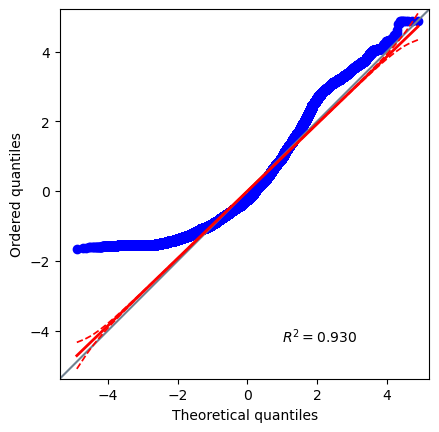

In [65]:
_ = pg.qqplot(accepted["installment"], dist='norm')

In [66]:
optb = OptimalBinning(name="installment", dtype="numerical", solver="cp")
optb.fit(x=accepted["installment"], y=accepted["default"])
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 109.95)",69443,0.051,59047,10396,0.150,0.428,0.008,0.001
1,"[109.95, 161.80)",77180,0.056,65316,11864,0.154,0.397,0.008,0.001
2,"[161.80, 219.40)",131751,0.096,108727,23024,0.175,0.243,0.005,0.001
3,"[219.40, 252.97)",74847,0.055,60983,13864,0.185,0.172,0.002,0.000
4,"[252.97, 334.82)",228454,0.167,180636,47818,0.209,0.020,0.000,0.000
5,"[334.82, 501.74)",335455,0.245,259320,76135,0.227,-0.083,0.002,0.000
6,"[501.74, 877.46)",350221,0.256,267925,82296,0.235,-0.129,0.004,0.001
7,"[877.46, inf)",100227,0.073,74797,25430,0.254,-0.230,0.004,0.001
8,Special,0,0.000,0,0,0.000,0.000,0.000,0.000
9,Missing,0,0.000,0,0,0.000,0.000,0.000,0.000


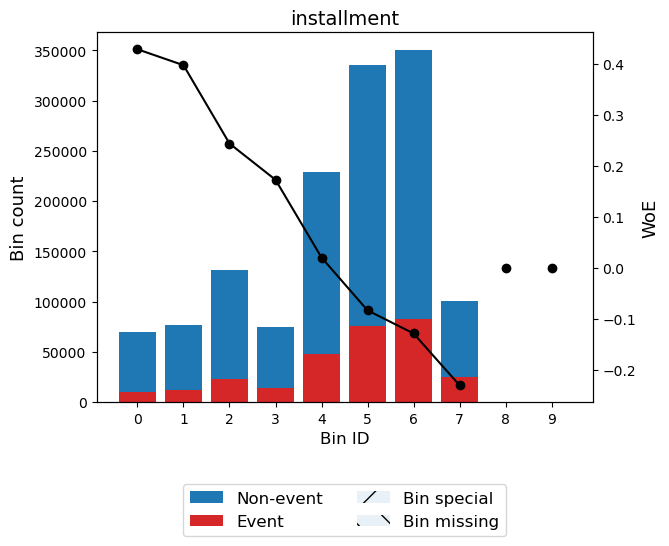

In [67]:
optb.binning_table.plot(metric="woe")

grade

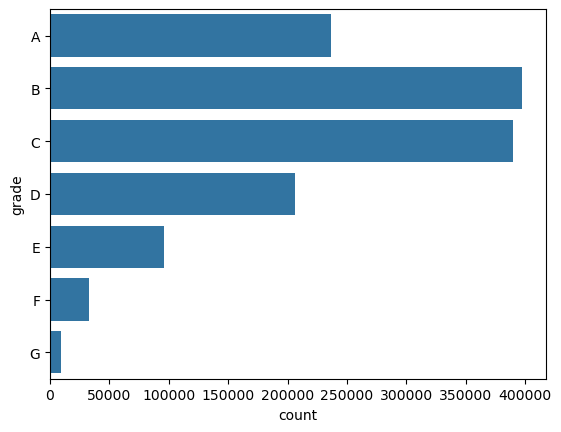

In [68]:
_ = sns.countplot(accepted["grade"], order=sorted(accepted["grade"].unique()))

In [201]:
ct = pd.crosstab(accepted["grade"], accepted["default"])
ct

default,0,1
grade,,
A,220889,15536
B,340172,57449
C,296037,93359
D,139899,66025
E,57615,38365
F,17567,15225
G,4572,4868


In [70]:
pd.crosstab(accepted["grade"], accepted["default"], normalize="all")

default,0,1
grade,,
A,0.162,0.011
B,0.249,0.042
C,0.216,0.068
D,0.102,0.048
E,0.042,0.028
F,0.013,0.011
G,0.003,0.004


In [71]:
pd.crosstab(accepted["grade"], accepted["default"], normalize="index")

default,0,1
grade,,
A,0.934,0.066
B,0.856,0.144
C,0.760,0.240
D,0.679,0.321
E,0.600,0.400
F,0.536,0.464
G,0.484,0.516


In [72]:
pd.crosstab(accepted["grade"], accepted["default"], normalize="columns")

default,0,1
grade,,
A,0.205,0.053
B,0.316,0.198
C,0.275,0.321
D,0.130,0.227
E,0.054,0.132
F,0.016,0.052
G,0.004,0.017


In [73]:
stats.pearson_chi2(accepted, "default", selected_columns=["grade"])

,feature,statistic,pvalue
0,grade,95209.381,0.000


In [202]:
association(ct, method='cramer')

0.2638540828908498

In [74]:
optb = OptimalBinning(name="grade", dtype="categorical", solver="cp")
optb.fit(x=accepted["grade"], y=accepted["default"])
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,[A],236425,0.173,220889,15536,0.066,1.346,0.204,0.024
1,[B],397621,0.291,340172,57449,0.144,0.470,0.056,0.007
2,[C],389396,0.285,296037,93359,0.240,-0.155,0.007,0.001
3,[D],205924,0.151,139899,66025,0.321,-0.558,0.054,0.007
4,"[E, F, G]",138212,0.101,79754,58458,0.423,-0.998,0.127,0.015
5,Special,0,0.000,0,0,0.000,0.000,0.000,0.000
6,Missing,0,0.000,0,0,0.000,0.000,0.000,0.000
Totals,,1367578,1.000,1076751,290827,0.213,,0.448,0.053


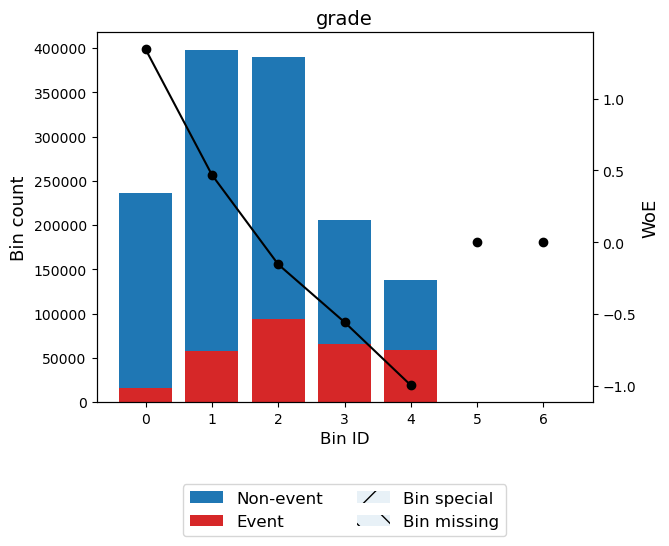

In [75]:
optb.binning_table.plot(metric="woe")

Will need to remove this column, since the goal an application scorecard is to make its own grade

emp_length

In [76]:
accepted["emp_length"].head()

0    10+ years
1    10+ years
2    10+ years
4      3 years
5      4 years
Name: emp_length, dtype: object

In [77]:
accepted["emp_length"].unique()

array(['10+ years', '3 years', '4 years', '6 years', '7 years', '8 years',
       '2 years', '5 years', '9 years', '< 1 year', '1 year', '0'],
      dtype=object)

In [78]:
accepted["employment_length"] = accepted["emp_length"].str.replace("+ years", "")
accepted["employment_length"] = accepted["employment_length"].str.replace(" years", "")
accepted["employment_length"] = accepted["employment_length"].str.replace(" year", "")
accepted["employment_length"] = accepted["employment_length"].str.replace("< 1", "0")
accepted["employment_length"] = accepted["employment_length"].astype(int)
accepted["employment_length"].head()

0    10
1    10
2    10
4     3
5     4
Name: employment_length, dtype: int64

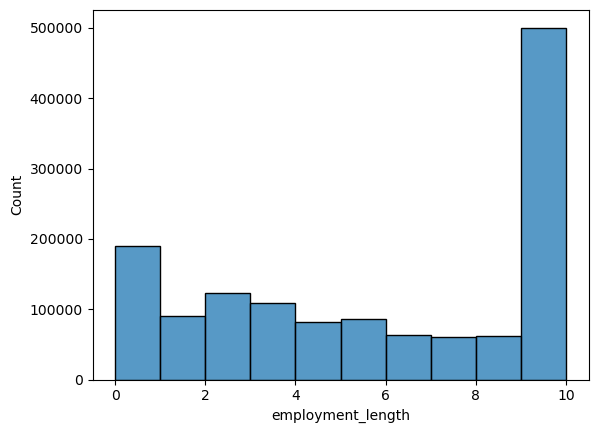

In [79]:
_ = sns.histplot(accepted["employment_length"], bins=10)

In [80]:
stats.kstests(accepted, "default", selected_columns=["employment_length"])

,feature,statistic,pvalue
0,employment_length,0.032,0.000


In [81]:
stats.pearson_chi2(accepted, "default", selected_columns=["emp_length"])

,feature,statistic,pvalue
0,emp_length,3139.242,0.000


In [203]:
ct = pd.crosstab(accepted["emp_length"], accepted["default"])
ct

default,0,1
emp_length,,
0,57381,23001
1 year,70296,19732
10+ years,359142,89796
2 years,97629,26168
3 years,86111,23357
4 years,64656,17371
5 years,67659,17864
6 years,50593,13104
7 years,48004,12423


In [83]:
pd.crosstab(accepted["emp_length"], accepted["default"], normalize="all")

default,0,1
emp_length,,
0,0.042,0.017
1 year,0.051,0.014
10+ years,0.263,0.066
2 years,0.071,0.019
3 years,0.063,0.017
4 years,0.047,0.013
5 years,0.049,0.013
6 years,0.037,0.010
7 years,0.035,0.009


In [84]:
pd.crosstab(accepted["emp_length"], accepted["default"], normalize="index")

default,0,1
emp_length,,
0,0.714,0.286
1 year,0.781,0.219
10+ years,0.800,0.200
2 years,0.789,0.211
3 years,0.787,0.213
4 years,0.788,0.212
5 years,0.791,0.209
6 years,0.794,0.206
7 years,0.794,0.206


In [204]:
stats.pearson_chi2(accepted, "default", selected_columns=["emp_length"])

,feature,statistic,pvalue
0,emp_length,3139.242,0.000


In [205]:
association(ct, method="cramer")

0.04791111981083526

In [85]:
optb = OptimalBinning(name="employment_length", dtype="numerical", solver="cp")
optb.fit(x=accepted["employment_length"], y=accepted["default"])
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",190586,0.139,143260,47326,0.248,-0.201,0.006,0.001
1,"[0.50, 1.50)",90028,0.066,70296,19732,0.219,-0.039,0.000,0.000
2,"[1.50, 3.50)",233265,0.171,183740,49525,0.212,0.002,0.000,0.000
3,"[3.50, 4.50)",82027,0.060,64656,17371,0.212,0.005,0.000,0.000
4,"[4.50, 5.50)",85523,0.063,67659,17864,0.209,0.023,0.000,0.000
5,"[5.50, 9.50)",237211,0.173,187998,49213,0.207,0.031,0.000,0.000
6,"[9.50, inf)",448938,0.328,359142,89796,0.200,0.077,0.002,0.000
7,Special,0,0.000,0,0,0.000,0.000,0.000,0.000
8,Missing,0,0.000,0,0,0.000,0.000,0.000,0.000
Totals,,1367578,1.000,1076751,290827,0.213,,0.008,0.001


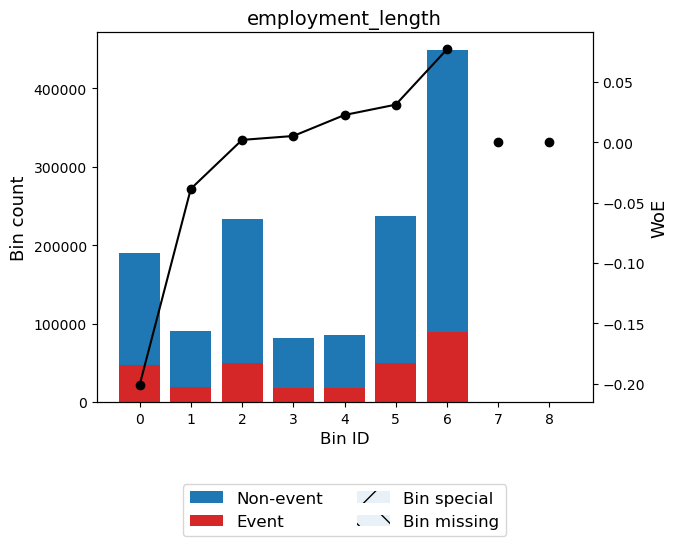

In [86]:
optb.binning_table.plot(metric="woe")

In [87]:
optb = OptimalBinning(name="emp_length", dtype="categorical", solver="cp")
optb.fit(x=accepted["emp_length"], y=accepted["default"])
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,[10+ years],448938,0.328,359142,89796,0.200,0.077,0.002,0.000
1,"[7 years, 6 years]",124124,0.091,98597,25527,0.206,0.042,0.000,0.000
2,[5 years],85523,0.063,67659,17864,0.209,0.023,0.000,0.000
3,"[9 years, 8 years]",113087,0.083,89401,23686,0.209,0.019,0.000,0.000
4,[2 years],123797,0.091,97629,26168,0.211,0.008,0.000,0.000
5,[4 years],82027,0.060,64656,17371,0.212,0.005,0.000,0.000
6,[3 years],109468,0.080,86111,23357,0.213,-0.004,0.000,0.000
7,[1 year],90028,0.066,70296,19732,0.219,-0.039,0.000,0.000
8,[< 1 year],110204,0.081,85879,24325,0.221,-0.048,0.000,0.000
9,[0],80382,0.059,57381,23001,0.286,-0.395,0.010,0.001


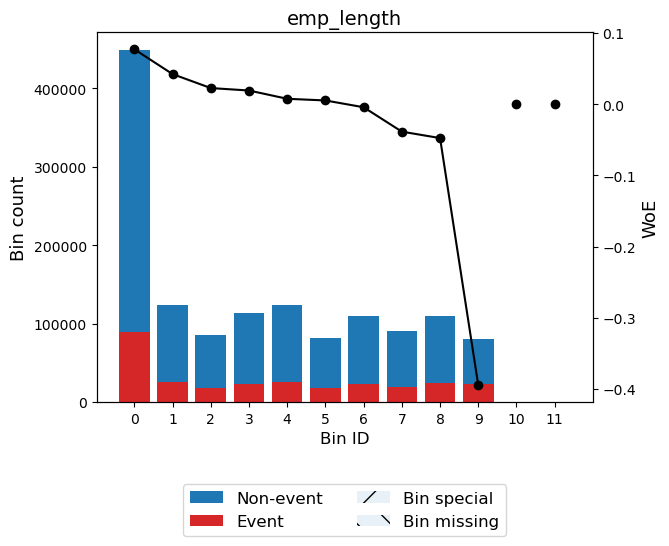

In [88]:
optb.binning_table.plot(metric="woe")

home_ownership

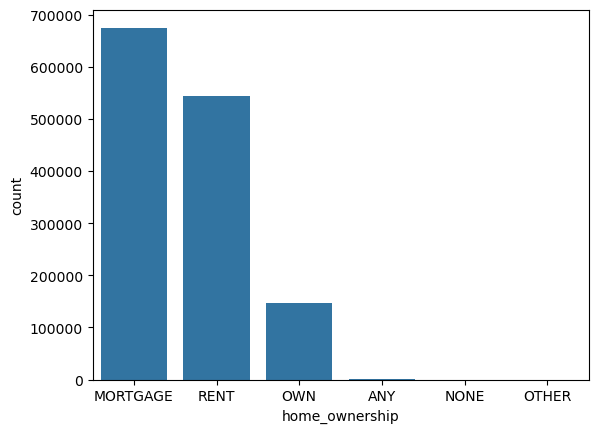

In [89]:
_ = sns.countplot(data=accepted, x="home_ownership")

In [206]:
ct = pd.crosstab(accepted["home_ownership"], accepted["default"])
ct

default,0,1
home_ownership,,
ANY,230,74
MORTGAGE,551048,124204
NONE,41,8
OTHER,117,38
OWN,114968,32607
RENT,410347,133896


In [91]:
pd.crosstab(accepted["home_ownership"], accepted["default"], normalize="all")

default,0,1
home_ownership,,
ANY,0.000,0.000
MORTGAGE,0.403,0.091
NONE,0.000,0.000
OTHER,0.000,0.000
OWN,0.084,0.024
RENT,0.300,0.098


In [92]:
pd.crosstab(accepted["home_ownership"], accepted["default"], normalize="index")

default,0,1
home_ownership,,
ANY,0.757,0.243
MORTGAGE,0.816,0.184
NONE,0.837,0.163
OTHER,0.755,0.245
OWN,0.779,0.221
RENT,0.754,0.246


In [93]:
stats.pearson_chi2(accepted, "default", selected_columns=["home_ownership"])

,feature,statistic,pvalue
0,home_ownership,7009.114,0.000


In [207]:
association(ct, method="cramer")

0.07159051731420794

In [94]:
optb = OptimalBinning(name="home_ownership", dtype="categorical", solver="cp")
optb.fit(x=accepted["home_ownership"], y=accepted["default"])
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"[NONE, MORTGAGE]",675301,0.494,551089,124212,0.184,0.181,0.015,0.002
1,[OWN],147575,0.108,114968,32607,0.221,-0.049,0.000,0.000
2,"[ANY, OTHER, RENT]",544702,0.398,410694,134008,0.246,-0.189,0.015,0.002
3,Special,0,0.000,0,0,0.000,0.000,0.000,0.000
4,Missing,0,0.000,0,0,0.000,0.000,0.000,0.000
Totals,,1367578,1.000,1076751,290827,0.213,,0.031,0.004


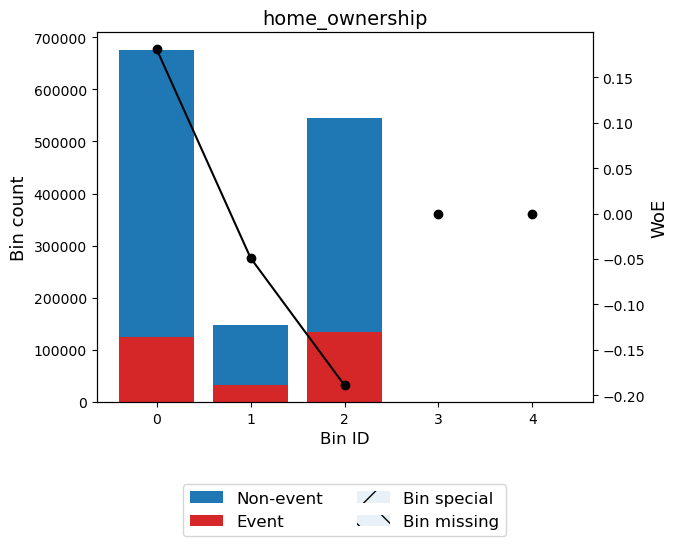

In [95]:
optb.binning_table.plot(metric="woe")

annual_inc 

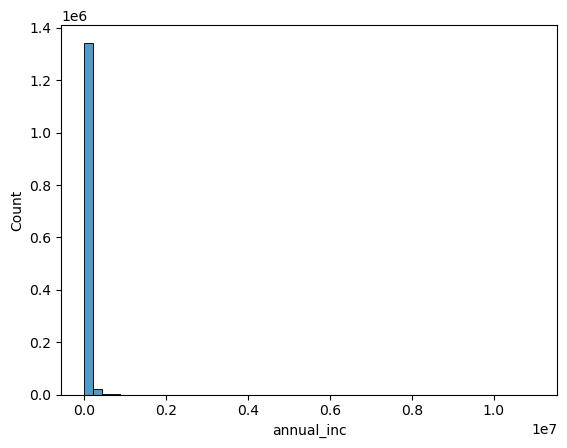

In [96]:
_ = sns.histplot(accepted["annual_inc"], bins=50)

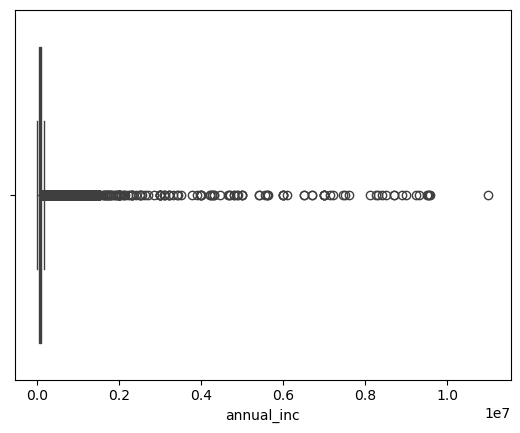

In [97]:
_ = sns.boxplot(data=accepted, x="annual_inc")

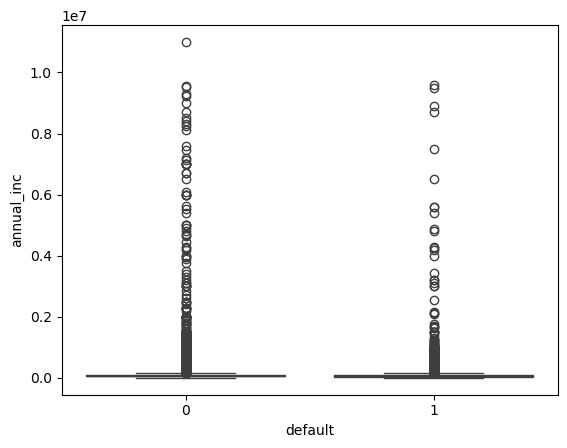

In [98]:
_ = sns.boxplot(data=accepted, x="default", y="annual_inc")

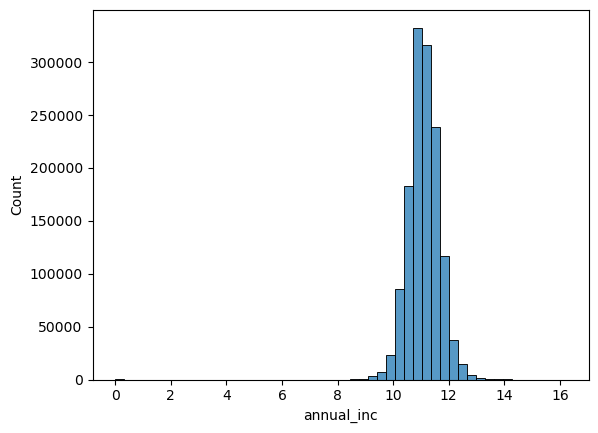

In [99]:
logged_income = np.log(accepted["annual_inc"] + 1)
_ = sns.histplot(logged_income, bins=50)

The zeros might be skewing

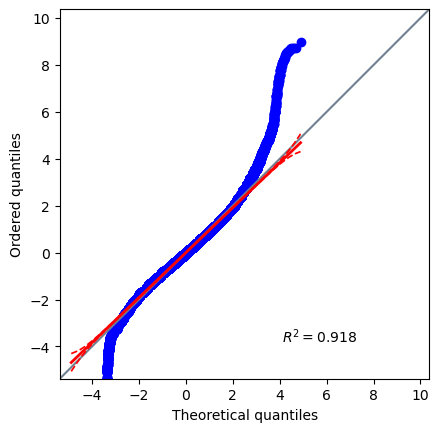

In [100]:
_ = pg.qqplot(logged_income, dist='norm')

In [101]:
accepted['logged_income'] = logged_income
stats.kstests(accepted, "default", selected_columns=["logged_income", "annual_inc"])

,feature,statistic,pvalue
0,logged_income,0.068,0.000
1,annual_inc,0.068,0.000


In [102]:
optb = OptimalBinning(name="annual_inc", dtype="numerical", solver="cp")
optb.fit(x=accepted["annual_inc"], y=accepted["default"])
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 30932.48)",103084,0.075,76472,26612,0.258,-0.253,0.005,0.001
1,"[30932.48, 36690.50)",77417,0.057,58308,19109,0.247,-0.193,0.002,0.000
2,"[36690.50, 40171.50)",70208,0.051,53363,16845,0.240,-0.156,0.001,0.000
3,"[40171.50, 45639.28)",90776,0.066,69394,21382,0.236,-0.132,0.001,0.000
4,"[45639.28, 50969.00)",101960,0.075,78602,23358,0.229,-0.096,0.001,0.000
5,"[50969.00, 60995.50)",187144,0.137,145175,41969,0.224,-0.068,0.001,0.000
6,"[60995.50, 65974.50)",81984,0.060,64205,17779,0.217,-0.025,0.000,0.000
7,"[65974.50, 70016.50)",72668,0.053,57352,15316,0.211,0.011,0.000,0.000
8,"[70016.50, 75365.50)",74205,0.054,58852,15353,0.207,0.035,0.000,0.000
9,"[75365.50, 86456.50)",124187,0.091,99192,24995,0.201,0.069,0.000,0.000


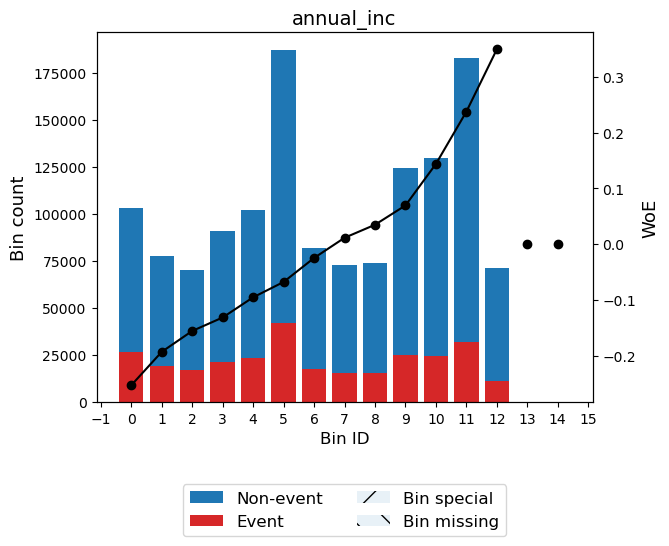

In [103]:
optb.binning_table.plot(metric="woe")

In [104]:
optb = OptimalBinning(name="logged_income", dtype="numerical", solver="cp")
optb.fit(x=accepted["logged_income"], y=accepted["default"])
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 10.34)",103084,0.075,76472,26612,0.258,-0.253,0.005,0.001
1,"[10.34, 10.51)",77417,0.057,58308,19109,0.247,-0.193,0.002,0.000
2,"[10.51, 10.60)",70208,0.051,53363,16845,0.240,-0.156,0.001,0.000
3,"[10.60, 10.73)",90776,0.066,69394,21382,0.236,-0.132,0.001,0.000
4,"[10.73, 10.84)",101960,0.075,78602,23358,0.229,-0.096,0.001,0.000
5,"[10.84, 11.02)",187144,0.137,145175,41969,0.224,-0.068,0.001,0.000
6,"[11.02, 11.10)",81984,0.060,64205,17779,0.217,-0.025,0.000,0.000
7,"[11.10, 11.16)",72668,0.053,57352,15316,0.211,0.011,0.000,0.000
8,"[11.16, 11.23)",74205,0.054,58852,15353,0.207,0.035,0.000,0.000
9,"[11.23, 11.37)",124187,0.091,99192,24995,0.201,0.069,0.000,0.000


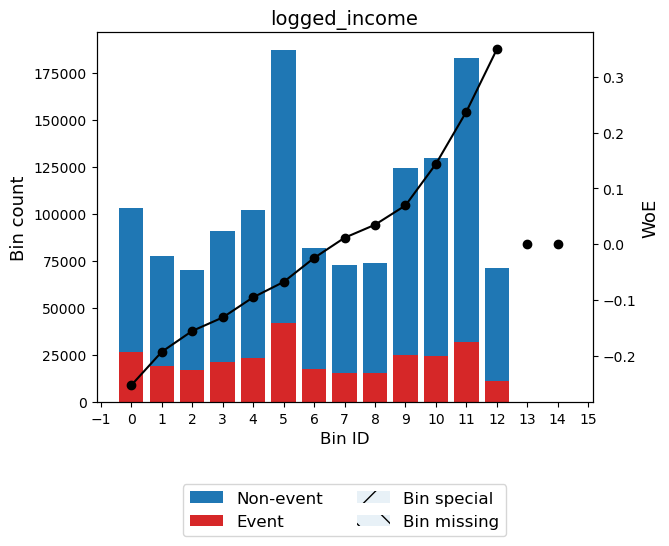

In [105]:
optb.binning_table.plot(metric="woe")

verification_status

In [106]:
accepted["verification_status"].unique()

array(['Not Verified', 'Source Verified', 'Verified'], dtype=object)

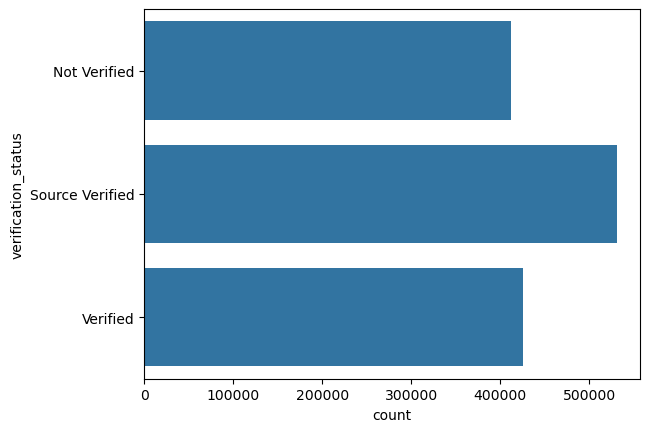

In [107]:
_ = sns.countplot(accepted["verification_status"])

In [208]:
ct = pd.crosstab(accepted["verification_status"], accepted["default"])
ct

default,0,1
verification_status,,
Not Verified,346166,65773
Source Verified,412041,118379
Verified,318544,106675


In [109]:
pd.crosstab(accepted["verification_status"], accepted["default"], normalize='all')

default,0,1
verification_status,,
Not Verified,0.253,0.048
Source Verified,0.301,0.087
Verified,0.233,0.078


In [110]:
pd.crosstab(accepted["verification_status"], accepted["default"], normalize='index')

default,0,1
verification_status,,
Not Verified,0.840,0.160
Source Verified,0.777,0.223
Verified,0.749,0.251


Income verification indicates higher default rate??

In [111]:
pd.crosstab(accepted["verification_status"], accepted["default"], normalize='columns')

default,0,1
verification_status,,
Not Verified,0.321,0.226
Source Verified,0.383,0.407
Verified,0.296,0.367


In [112]:
stats.pearson_chi2(accepted, "default", selected_columns=["verification_status"])

,feature,statistic,pvalue
0,verification_status,10967.742,0.000


In [209]:
association(ct, method="cramer")

0.08955349732752695

In [113]:
optb = OptimalBinning(name="verification_status", dtype="categorical", solver="cp")
optb.fit(x=accepted["verification_status"], y=accepted["default"])
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,[Not Verified],411939,0.301,346166,65773,0.160,0.352,0.034,0.004
1,[Source Verified],530420,0.388,412041,118379,0.223,-0.062,0.002,0.000
2,[Verified],425219,0.311,318544,106675,0.251,-0.215,0.015,0.002
3,Special,0,0.000,0,0,0.000,0.000,0.000,0.000
4,Missing,0,0.000,0,0,0.000,0.000,0.000,0.000
Totals,,1367578,1.000,1076751,290827,0.213,,0.050,0.006


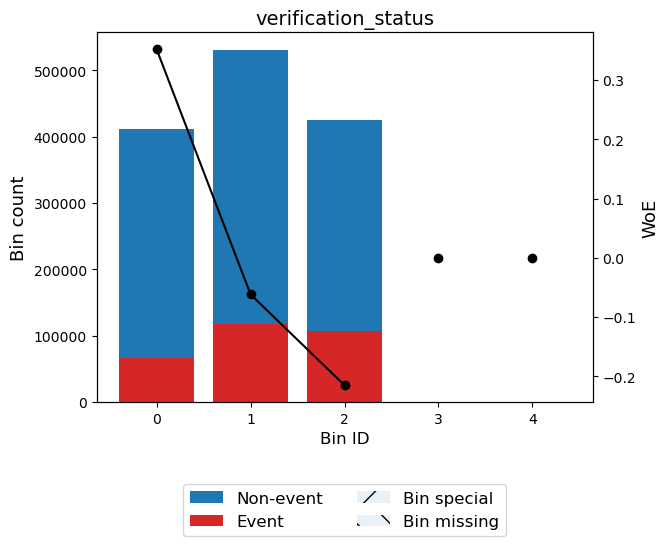

In [114]:
optb.binning_table.plot(metric="woe")

issue_d

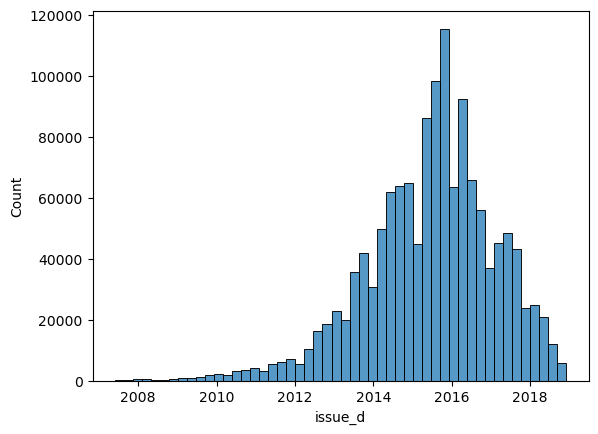

In [115]:
_ = sns.histplot(accepted["issue_d"], bins=50)

Purpose

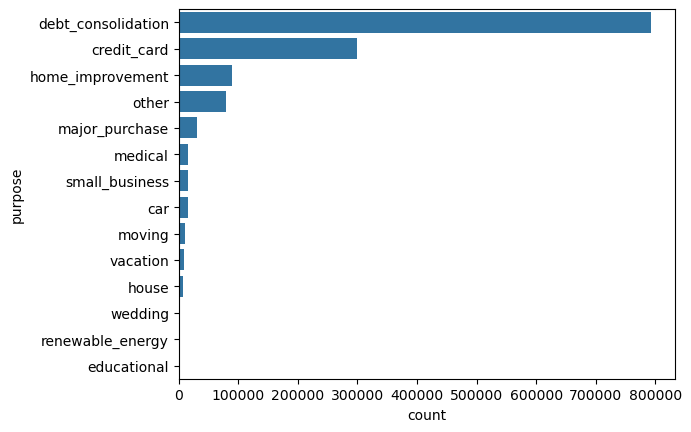

In [116]:
_ = sns.countplot(accepted["purpose"], order=accepted["purpose"].value_counts().index)

In [211]:
ct = pd.crosstab(accepted["purpose"], accepted["default"])
ct

default,0,1
purpose,,
car,12444,2349
credit_card,245297,54071
debt_consolidation,615307,177802
educational,270,88
home_improvement,72002,17017
house,5666,1786
major_purchase,23952,6066
medical,12167,3705
moving,7266,2407


In [210]:
stats.pearson_chi2(accepted, "default", selected_columns=["purpose"])

,feature,statistic,pvalue
0,purpose,4351.962,0.000


In [212]:
association(ct, method="cramer")    

0.05641134886531839

This would definitely benefit from WoE encoding

In [118]:
optb = OptimalBinning(name="purpose", dtype="categorical", solver="cp")

In [119]:
optb.fit(x=accepted["purpose"], y=accepted["default"])

OptimalBinning(dtype='categorical', name='purpose')

In [120]:
optb.status

'OPTIMAL'

In [121]:
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"[wedding, car, credit_card]",316468,0.231,259756,56712,0.179,0.213,0.010,0.001
1,"[home_improvement, major_purchase]",119037,0.087,95954,23083,0.194,0.116,0.001,0.000
2,"[vacation, debt_consolidation]",802341,0.587,622634,179707,0.224,-0.066,0.003,0.000
3,"[other, medical, house, educational, moving, r...",129732,0.095,98407,31325,0.241,-0.164,0.003,0.000
4,Special,0,0.000,0,0,0.000,0.000,0.000,0.000
5,Missing,0,0.000,0,0,0.000,0.000,0.000,0.000
Totals,,1367578,1.000,1076751,290827,0.213,,0.016,0.002


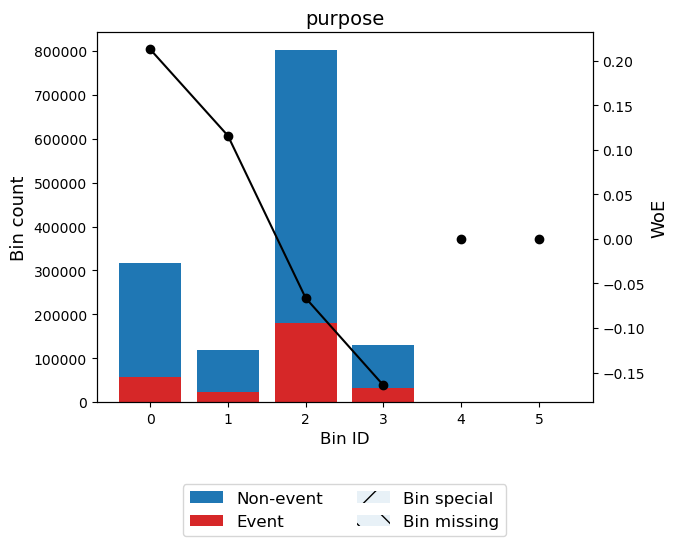

In [122]:
optb.binning_table.plot(metric="woe")

IV is very low, might not be useful for prediction

addr_state

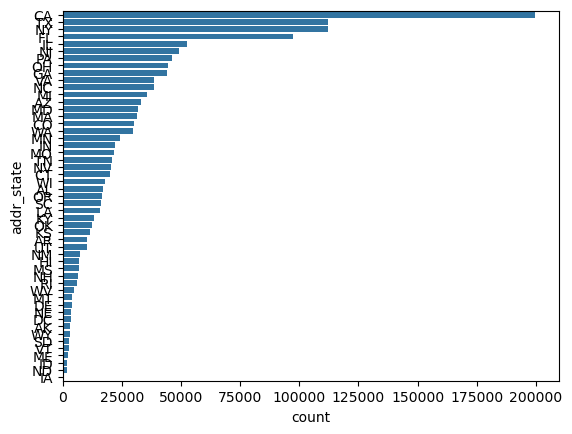

In [123]:
_ = sns.countplot(accepted["addr_state"], order=accepted["addr_state"].value_counts().index)

In [124]:
pd.crosstab(accepted["addr_state"], accepted["default"])

default,0,1
addr_state,,
AK,2563,679
AL,12687,4235
AR,7627,2602
AZ,26277,6915
CA,157988,41641
CO,25064,4968
CT,16300,3767
DC,3016,502
DE,3036,805


In [125]:
stats.pearson_chi2(accepted, "default", selected_columns=["addr_state"])

,feature,statistic,pvalue
0,addr_state,None,None


In [126]:
optb = OptimalBinning(name="addr_state", dtype="categorical", solver="cp")
optb.fit(x=accepted["addr_state"], y=accepted["default"])
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"[DC, VT, ME, OR, NH, WV, CO, WA, SC, WY, KS, MT]",130394,0.095,108733,21661,0.166,0.304,0.008,0.001
1,"[UT, CT, RI, IL, GA, WI]",150799,0.110,121682,29117,0.193,0.121,0.002,0.000
2,"[MA, AZ, CA, ID, MN, AK, DE]",297431,0.217,235546,61885,0.208,0.028,0.000,0.000
3,"[TX, VA]",150752,0.110,118785,31967,0.212,0.004,0.000,0.000
4,"[HI, OH, MI]",87065,0.064,68317,18748,0.215,-0.016,0.000,0.000
5,"[NC, PA, KY]",97713,0.071,76133,21580,0.221,-0.048,0.000,0.000
6,"[SD, NJ, NM, IN, TN, ND, MO]",125618,0.092,97277,28341,0.226,-0.076,0.001,0.000
7,"[MD, FL, NV]",149954,0.110,115472,34482,0.230,-0.100,0.001,0.000
8,"[NY, LA, OK, AL, AR, NE, MS, IA]",177852,0.130,134806,43046,0.242,-0.167,0.004,0.000
9,Special,0,0.000,0,0,0.000,0.000,0.000,0.000


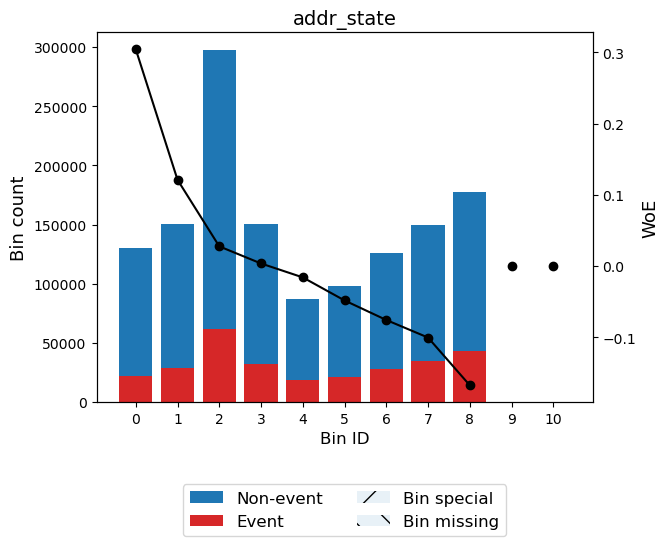

In [127]:
optb.binning_table.plot(metric="woe")

In [128]:
bin_0 = ['DC', 'VT', 'ME', 'OR', 'NH', 'WV', 'CO', 'WA', 'SC', 'WY', 'KS', 'MT']
bin_1 = ['UT', 'CT', 'RI', 'IL', 'GA', 'WI']
bin_2 = ['MA', 'AZ', 'CA', 'ID', 'MN', 'AK', 'DE']
bin_3 = ['TX', 'VA']
bin_4 = ['HI', 'OH', 'MI']
bin_5 = ['NC', 'PA', 'KY']
bin_6 = ['SD', 'NJ', 'NM', 'IN', 'TN', 'ND', 'MO']
bin_7 = ['MD', 'FL', 'NV']
bin_8 = ['NY', 'LA', 'OK', 'AL', 'AR', 'NE', 'MS', 'IA']

In [129]:
accepted["addr_state_binned"] = accepted["addr_state"]
accepted.loc[accepted["addr_state"].isin(bin_0), "addr_state_binned"] = "bin_0"
accepted.loc[accepted["addr_state"].isin(bin_1), "addr_state_binned"] = "bin_1" 
accepted.loc[accepted["addr_state"].isin(bin_2), "addr_state_binned"] = "bin_2" 
accepted.loc[accepted["addr_state"].isin(bin_3), "addr_state_binned"] = "bin_3" 
accepted.loc[accepted["addr_state"].isin(bin_4), "addr_state_binned"] = "bin_4" 
accepted.loc[accepted["addr_state"].isin(bin_5), "addr_state_binned"] = "bin_5" 
accepted.loc[accepted["addr_state"].isin(bin_6), "addr_state_binned"] = "bin_6" 
accepted.loc[accepted["addr_state"].isin(bin_7), "addr_state_binned"] = "bin_7" 
accepted.loc[accepted["addr_state"].isin(bin_8), "addr_state_binned"] = "bin_8"

In [130]:
stats.pearson_chi2(accepted, "default", selected_columns=["addr_state_binned"])

,feature,statistic,pvalue
0,addr_state_binned,3422.708,0.000


In [214]:
ct = pd.crosstab(accepted["addr_state_binned"], accepted["default"])
ct

default,0,1
addr_state_binned,,
bin_0,108733,21661
bin_1,121682,29117
bin_2,235546,61885
bin_3,118785,31967
bin_4,68317,18748
bin_5,76133,21580
bin_6,97277,28341
bin_7,115472,34482
bin_8,134806,43046


In [132]:
pd.crosstab(accepted["addr_state_binned"], accepted["default"], normalize="all")

default,0,1
addr_state_binned,,
bin_0,0.080,0.016
bin_1,0.089,0.021
bin_2,0.172,0.045
bin_3,0.087,0.023
bin_4,0.050,0.014
bin_5,0.056,0.016
bin_6,0.071,0.021
bin_7,0.084,0.025
bin_8,0.099,0.031


In [133]:
pd.crosstab(accepted["addr_state_binned"], accepted["default"], normalize="index")

default,0,1
addr_state_binned,,
bin_0,0.834,0.166
bin_1,0.807,0.193
bin_2,0.792,0.208
bin_3,0.788,0.212
bin_4,0.785,0.215
bin_5,0.779,0.221
bin_6,0.774,0.226
bin_7,0.770,0.230
bin_8,0.758,0.242


In [213]:
stats.pearson_chi2(accepted, "default", selected_columns=["addr_state_binned"])

,feature,statistic,pvalue
0,addr_state_binned,3422.708,0.000


In [216]:
association(ct, method="cramer")

0.050027509359492864

dti

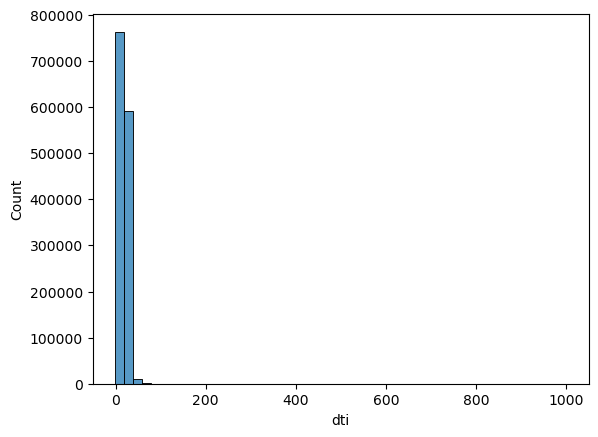

In [134]:
_ = sns.histplot(accepted["dti"], bins=50)

In [135]:
dti_maxed = accepted[accepted["dti"] < 100]

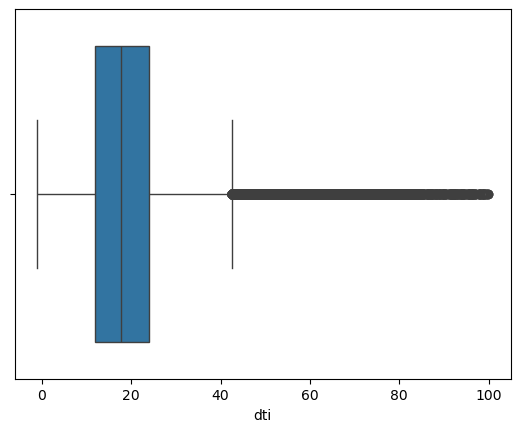

In [136]:
_ = sns.boxplot(data=dti_maxed, x="dti")

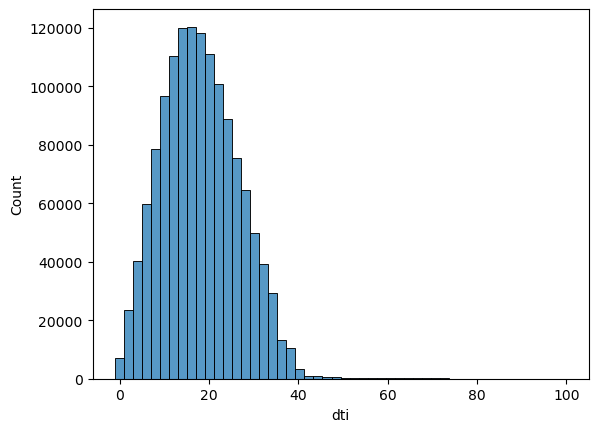

In [137]:
_ = sns.histplot(dti_maxed["dti"], bins=50)

In [138]:
stats.kstests(dti_maxed, "default", selected_columns=["dti"])

,feature,statistic,pvalue
0,dti,0.111,0.000


In [139]:
stats.kstests(accepted, "default", selected_columns=["dti"])

,feature,statistic,pvalue
0,dti,0.111,0.000


In [140]:
optb = OptimalBinning(name="dti", dtype="numerical", solver="cp")
optb.fit(x=accepted["dti"], y=accepted["default"])
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 8.98)",204362,0.149,171383,32979,0.161,0.339,0.016,0.002
1,"[8.98, 10.93)",92103,0.067,76666,15437,0.168,0.294,0.005,0.001
2,"[10.93, 12.76)",98713,0.072,81493,17220,0.174,0.245,0.004,0.001
3,"[12.76, 14.85)",122901,0.090,100393,22508,0.183,0.186,0.003,0.000
4,"[14.85, 17.10)",134066,0.098,108014,26052,0.194,0.113,0.001,0.000
5,"[17.10, 18.26)",68458,0.050,54535,13923,0.203,0.056,0.000,0.000
6,"[18.26, 19.88)",93492,0.068,73814,19678,0.210,0.013,0.000,0.000
7,"[19.88, 21.70)",97541,0.071,76100,21441,0.220,-0.042,0.000,0.000
8,"[21.70, 23.61)",92560,0.068,71057,21503,0.232,-0.114,0.001,0.000
9,"[23.61, 25.39)",77409,0.057,58576,18833,0.243,-0.174,0.002,0.000


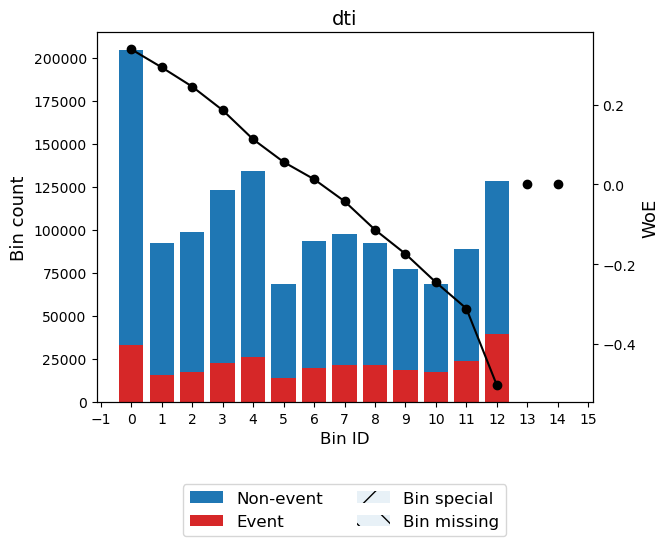

In [141]:
optb.binning_table.plot(metric="woe")

earliest_cr_line

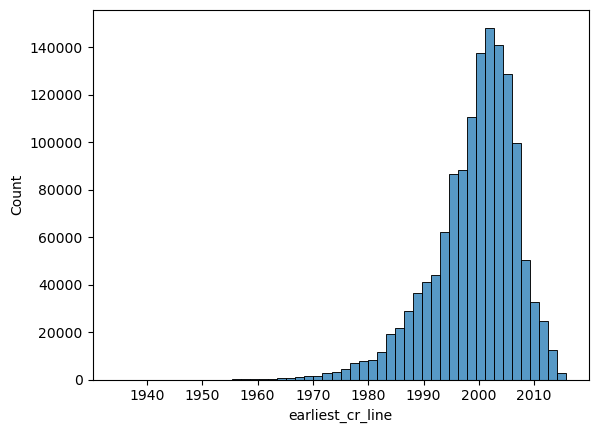

In [142]:
_ = sns.histplot(accepted["earliest_cr_line"], bins=50)

fico_range_low

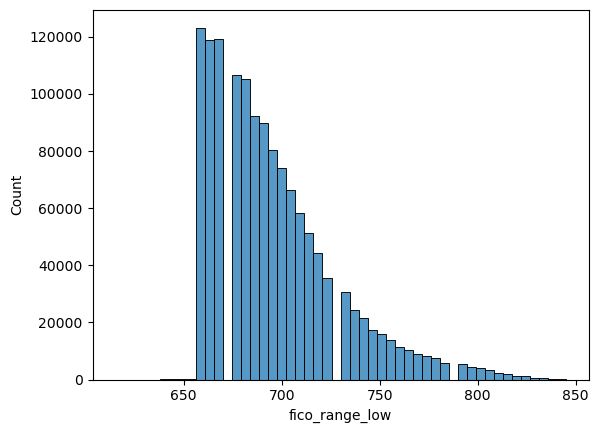

In [143]:
_ = sns.histplot(accepted["fico_range_low"], bins=50)

In [144]:
stats.kstests(accepted, "default", selected_columns=["fico_range_low"])

,feature,statistic,pvalue
0,fico_range_low,0.134,0.000


In [145]:
optb = OptimalBinning(name="fico_range_low", dtype="numerical", solver="cp")
optb.fit(x=accepted["fico_range_low"], y=accepted["default"])
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 662.50)",123368,0.090,88468,34900,0.283,-0.379,0.014,0.002
1,"[662.50, 667.50)",118993,0.087,86761,32232,0.271,-0.319,0.010,0.001
2,"[667.50, 672.50)",119212,0.087,88354,30858,0.259,-0.257,0.006,0.001
3,"[672.50, 677.50)",106452,0.078,79721,26731,0.251,-0.216,0.004,0.000
4,"[677.50, 682.50)",105129,0.077,79480,25649,0.244,-0.178,0.003,0.000
5,"[682.50, 687.50)",92271,0.067,71130,21141,0.229,-0.096,0.001,0.000
6,"[687.50, 692.50)",89675,0.066,69920,19755,0.220,-0.045,0.000,0.000
7,"[692.50, 697.50)",80354,0.059,63338,17016,0.212,0.005,0.000,0.000
8,"[697.50, 702.50)",73989,0.054,59076,14913,0.202,0.068,0.000,0.000
9,"[702.50, 717.50)",176138,0.129,144577,31561,0.179,0.213,0.005,0.001


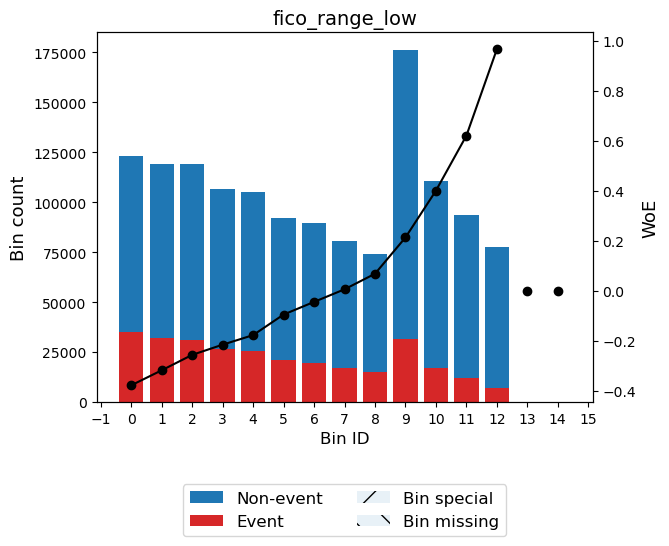

In [146]:
optb.binning_table.plot(metric="woe")

fico_range_high

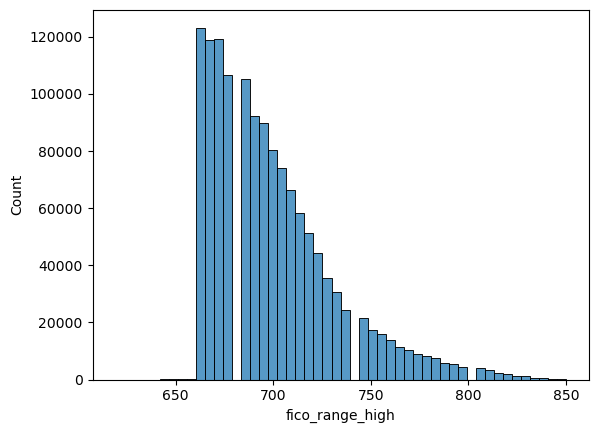

In [147]:
_ = sns.histplot(accepted["fico_range_high"], bins=50)

In [148]:
stats.kstests(accepted, "default", selected_columns=["fico_range_high"])

,feature,statistic,pvalue
0,fico_range_high,0.134,0.000


In [149]:
optb = OptimalBinning(name="fico_range_high", dtype="numerical", solver="cp")
optb.fit(x=accepted["fico_range_high"], y=accepted["default"])
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 666.50)",123368,0.090,88468,34900,0.283,-0.379,0.014,0.002
1,"[666.50, 671.50)",118993,0.087,86761,32232,0.271,-0.319,0.010,0.001
2,"[671.50, 676.50)",119212,0.087,88354,30858,0.259,-0.257,0.006,0.001
3,"[676.50, 681.50)",106452,0.078,79721,26731,0.251,-0.216,0.004,0.000
4,"[681.50, 686.50)",105129,0.077,79480,25649,0.244,-0.178,0.003,0.000
5,"[686.50, 691.50)",92271,0.067,71130,21141,0.229,-0.096,0.001,0.000
6,"[691.50, 696.50)",89675,0.066,69920,19755,0.220,-0.045,0.000,0.000
7,"[696.50, 701.50)",80354,0.059,63338,17016,0.212,0.005,0.000,0.000
8,"[701.50, 706.50)",73989,0.054,59076,14913,0.202,0.068,0.000,0.000
9,"[706.50, 721.50)",176138,0.129,144577,31561,0.179,0.213,0.005,0.001


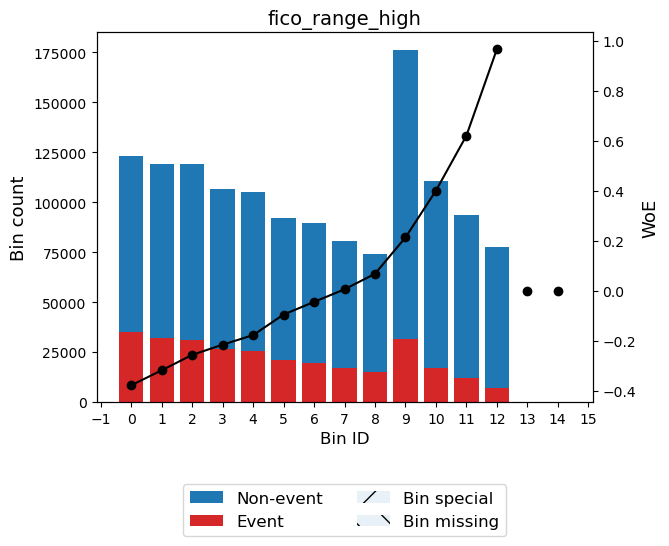

In [150]:
optb.binning_table.plot(metric="woe")

inq_last_6mths

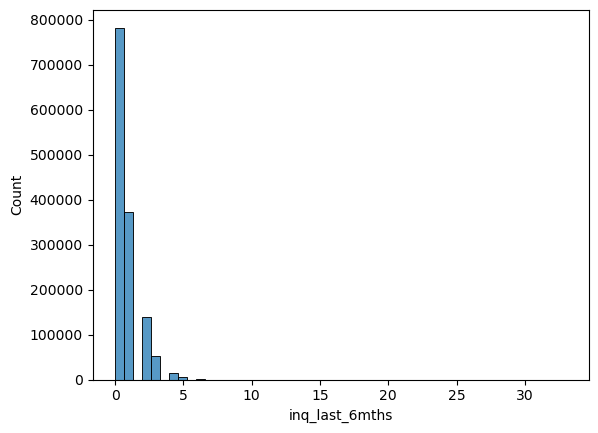

In [151]:
_ = sns.histplot(accepted["inq_last_6mths"], bins=50)

In [152]:
stats.kstests(accepted, "default", selected_columns=["inq_last_6mths"])

,feature,statistic,pvalue
0,inq_last_6mths,0.070,0.000


In [153]:
optb = OptimalBinning(name="inq_last_6mths", dtype="numerical", solver="cp")
optb.fit(x=accepted["inq_last_6mths"], y=accepted["default"])
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",782840,0.572,632376,150464,0.192,0.127,0.009,0.001
1,"[0.50, 1.50)",372753,0.273,288082,84671,0.227,-0.085,0.002,0.000
2,"[1.50, 2.50)",139023,0.102,103969,35054,0.252,-0.222,0.005,0.001
3,"[2.50, inf)",72962,0.053,52324,20638,0.283,-0.379,0.008,0.001
4,Special,0,0.000,0,0,0.000,0.000,0.000,0.000
5,Missing,0,0.000,0,0,0.000,0.000,0.000,0.000
Totals,,1367578,1.000,1076751,290827,0.213,,0.025,0.003


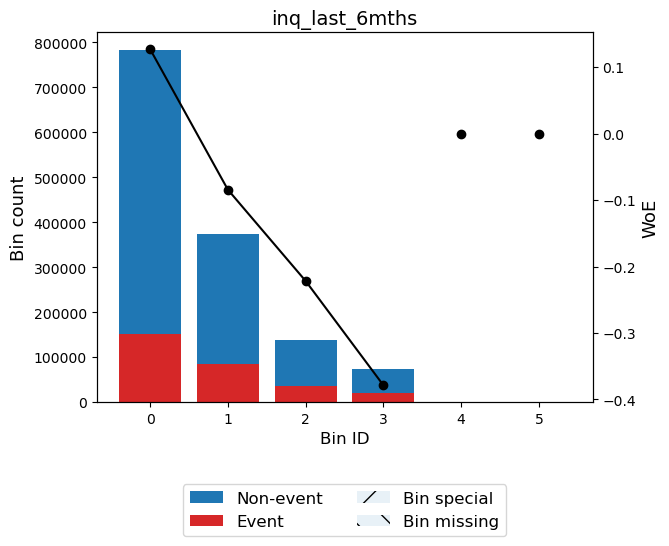

In [154]:
optb.binning_table.plot(metric="woe")

open_acc

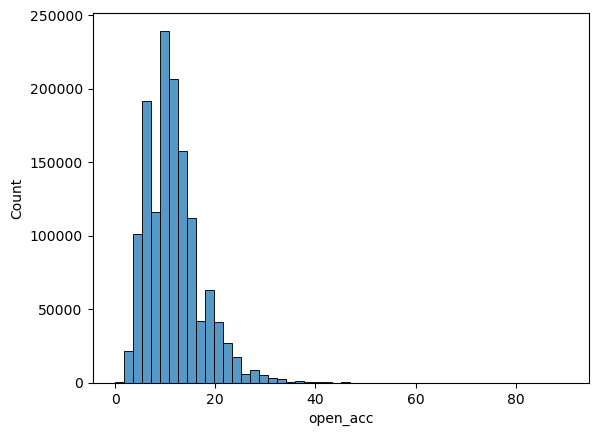

In [155]:
_ = sns.histplot(accepted["open_acc"], bins=50)

In [156]:
stats.kstests(accepted, "default", selected_columns=["open_acc"])

,feature,statistic,pvalue
0,open_acc,0.027,0.000


In [157]:
optb = OptimalBinning(name="open_acc", dtype="numerical", solver="cp")
optb.fit(x=accepted["open_acc"], y=accepted["default"])
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 6.50)",210421,0.154,168465,41956,0.199,0.081,0.001,0.000
1,"[6.50, 7.50)",104878,0.077,83735,21143,0.202,0.067,0.000,0.000
2,"[7.50, 8.50)",116400,0.085,92703,23697,0.204,0.055,0.000,0.000
3,"[8.50, 9.50)",121358,0.089,96359,24999,0.206,0.040,0.000,0.000
4,"[9.50, 10.50)",118162,0.086,93287,24875,0.211,0.013,0.000,0.000
5,"[10.50, 11.50)",108996,0.080,85593,23403,0.215,-0.012,0.000,0.000
6,"[11.50, 12.50)",97670,0.071,76621,21049,0.216,-0.017,0.000,0.000
7,"[12.50, 14.50)",157872,0.115,123613,34259,0.217,-0.026,0.000,0.000
8,"[14.50, 17.50)",153738,0.112,119822,33916,0.221,-0.047,0.000,0.000
9,"[17.50, 20.50)",85797,0.063,66474,19323,0.225,-0.073,0.000,0.000


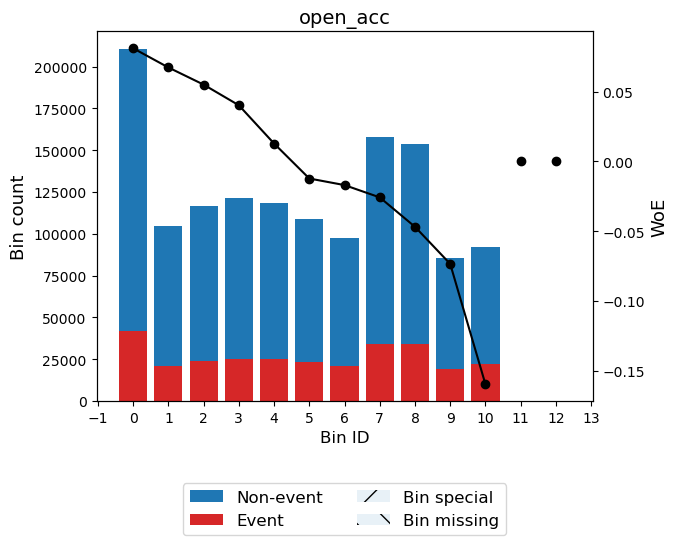

In [158]:
optb.binning_table.plot(metric="woe")

pub_rec

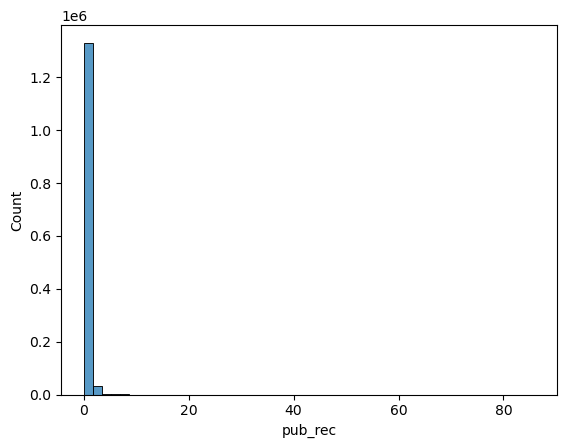

In [159]:
_ = sns.histplot(accepted["pub_rec"], bins=50)

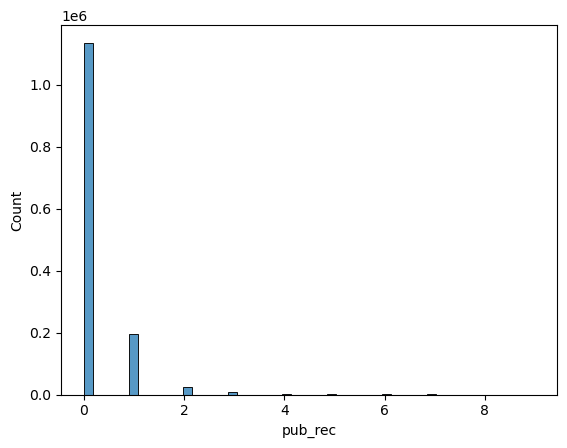

In [160]:
_ = sns.histplot(accepted[accepted["pub_rec"] < 10]["pub_rec"], bins=50)

In [161]:
stats.kstests(accepted, "default", selected_columns=["pub_rec"])

,feature,statistic,pvalue
0,pub_rec,0.029,0.000


In [162]:
optb = OptimalBinning(name="pub_rec", dtype="numerical", solver="cp")
optb.fit(x=accepted["pub_rec"], y=accepted["default"])
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 0.50)",1135564,0.830,900720,234844,0.207,0.035,0.001,0.000
1,"[0.50, inf)",232014,0.170,176031,55983,0.241,-0.163,0.005,0.001
2,Special,0,0.000,0,0,0.000,0.000,0.000,0.000
3,Missing,0,0.000,0,0,0.000,0.000,0.000,0.000
Totals,,1367578,1.000,1076751,290827,0.213,,0.006,0.001


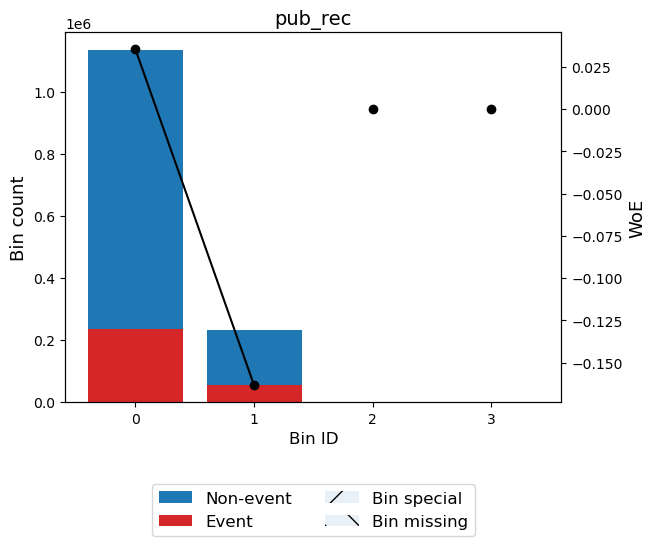

In [163]:
optb.binning_table.plot(metric="woe")

revol_bal

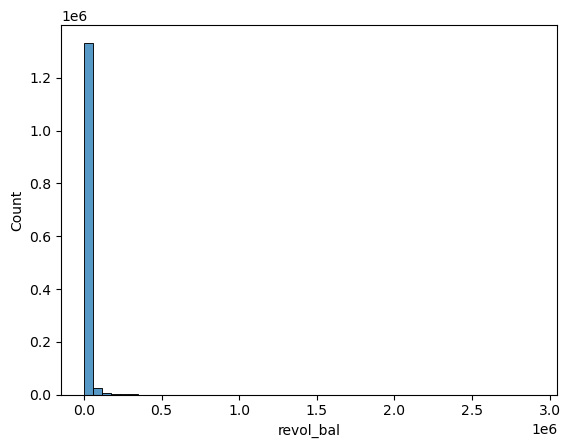

In [164]:
_ = sns.histplot(accepted["revol_bal"], bins=50)

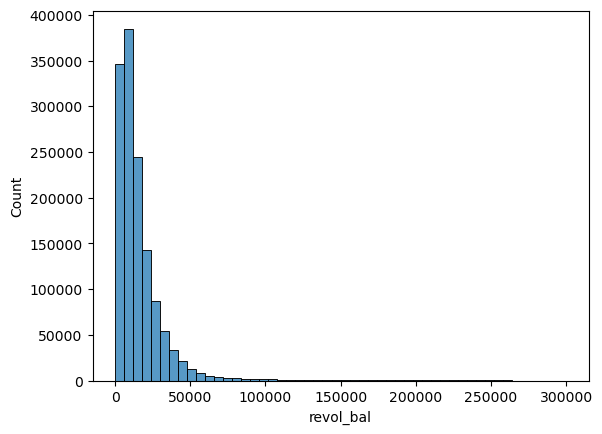

In [165]:
_ = sns.histplot(accepted[accepted["revol_bal"] <  300000]["revol_bal"], bins=50)

In [166]:
len(accepted["revol_bal"].unique())

84248

In [167]:
stats.kstests(accepted, "default", selected_columns=["revol_bal"])

,feature,statistic,pvalue
0,revol_bal,0.019,0.000


In [181]:
optb = OptimalBinning(name="revol_bal", dtype="numerical", solver="cp")
optb.fit(x=accepted["revol_bal"], y=accepted["default"])
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 6944.50)",415514,0.304,327152,88362,0.213,0.000,0.000,0.000
1,"[6944.50, 11513.50)",290343,0.212,227253,63090,0.217,-0.027,0.000,0.000
2,"[11513.50, 14637.50)",149418,0.109,116515,32903,0.220,-0.045,0.000,0.000
3,"[14637.50, 16449.50)",69939,0.051,54366,15573,0.223,-0.059,0.000,0.000
4,"[16449.50, 19051.50)",81943,0.060,63819,18124,0.221,-0.050,0.000,0.000
5,"[19051.50, 24334.50)",118303,0.087,92760,25543,0.216,-0.019,0.000,0.000
6,"[24334.50, 33925.50)",118578,0.087,94168,24410,0.206,0.041,0.000,0.000
7,"[33925.50, inf)",123540,0.090,100718,22822,0.185,0.176,0.003,0.000
8,Special,0,0.000,0,0,0.000,0.000,0.000,0.000
9,Missing,0,0.000,0,0,0.000,0.000,0.000,0.000


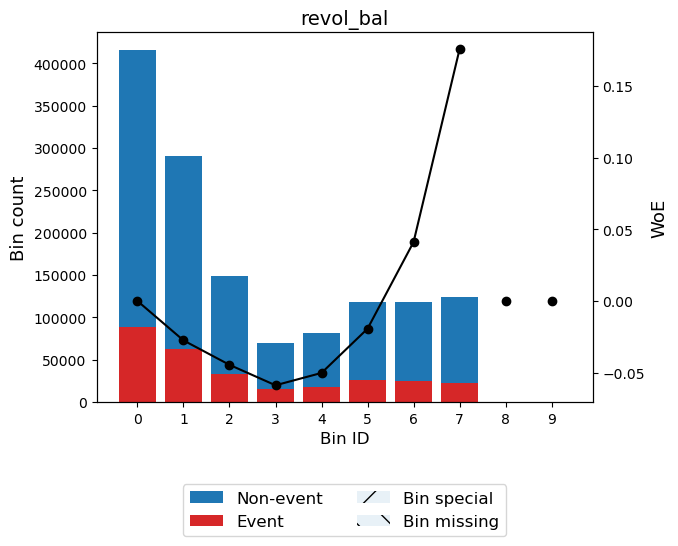

In [169]:
optb.binning_table.plot(metric="woe")

revol_util

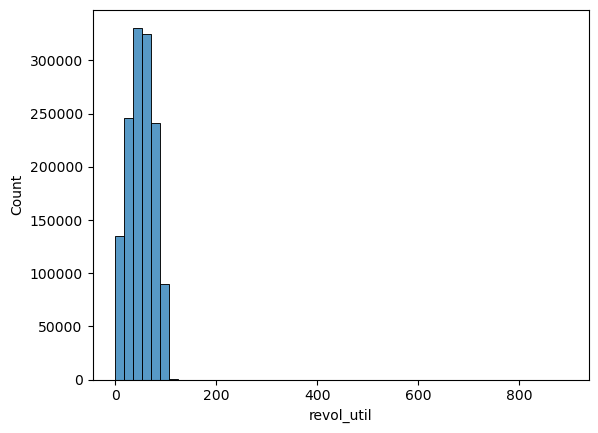

In [170]:
_ = sns.histplot(accepted["revol_util"], bins=50)

In [171]:
stats.kstests(accepted, "default", selected_columns=["revol_util"])

,feature,statistic,pvalue
0,revol_util,0.058,0.000


In [172]:
accepted["revol_util"] = accepted["revol_util"].astype(float)

In [185]:
optb = OptimalBinning(name="revol_util", dtype="numerical", solver="mip")
optb.fit(x=accepted["revol_util"], y=accepted["default"])
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 16.25)",118946,0.087,99478,19468,0.164,0.322,0.008,0.001
1,"[16.25, 23.25)",76771,0.056,63274,13497,0.176,0.236,0.003,0.000
2,"[23.25, 31.95)",123106,0.090,99885,23221,0.189,0.150,0.002,0.000
3,"[31.95, 38.78)",116128,0.085,92696,23432,0.202,0.066,0.000,0.000
4,"[38.78, 42.85)",73630,0.054,58304,15326,0.208,0.027,0.000,0.000
5,"[42.85, 47.95)",95229,0.070,74947,20282,0.213,-0.002,0.000,0.000
6,"[47.95, 51.85)",74609,0.055,58420,16189,0.217,-0.026,0.000,0.000
7,"[51.85, 56.55)",90867,0.066,70719,20148,0.222,-0.053,0.000,0.000
8,"[56.55, 63.85)",137099,0.100,105971,31128,0.227,-0.084,0.001,0.000
9,"[63.85, 74.75)",184533,0.135,142160,42373,0.230,-0.099,0.001,0.000


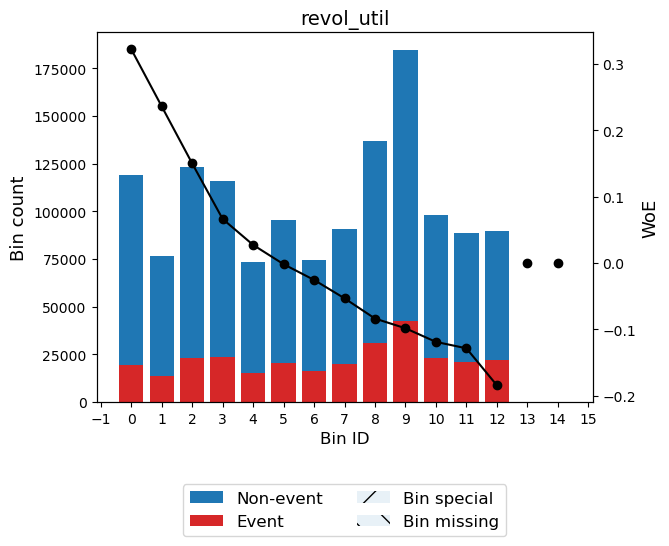

In [183]:
optb.binning_table.plot(metric="woe")

total_acc

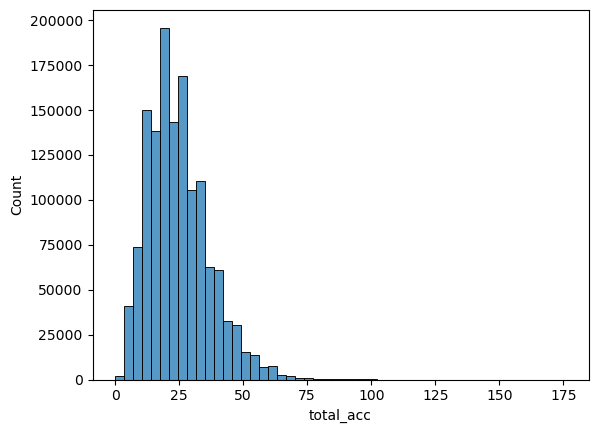

In [175]:
_ = sns.histplot(accepted["total_acc"], bins=50)

In [176]:
stats.kstests(accepted, "default", selected_columns=["total_acc"])

,feature,statistic,pvalue
0,total_acc,0.023,0.000


In [178]:
accepted["total_acc"]

0         13.000
1         38.000
2         18.000
4         35.000
5          6.000
           ...  
2260688   39.000
2260690   32.000
2260691   18.000
2260692   28.000
2260697   31.000
Name: total_acc, Length: 1367578, dtype: float64

In [186]:
optb = OptimalBinning(name="total_acc", dtype="numerical", solver="mip")
optb.fit(x=accepted["total_acc"], y=accepted["default"])
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 9.50)",87393,0.064,66962,20431,0.234,-0.122,0.001,0.000
1,"[9.50, 13.50)",137069,0.100,106025,31044,0.226,-0.081,0.001,0.000
2,"[13.50, 16.50)",132193,0.097,102888,29305,0.222,-0.053,0.000,0.000
3,"[16.50, 19.50)",145195,0.106,114056,31139,0.214,-0.011,0.000,0.000
4,"[19.50, 21.50)",98657,0.072,77704,20953,0.212,0.002,0.000,0.000
5,"[21.50, 25.50)",188732,0.138,149369,39363,0.209,0.025,0.000,0.000
6,"[25.50, 27.50)",84743,0.062,67299,17444,0.206,0.041,0.000,0.000
7,"[27.50, 29.50)",76262,0.056,60668,15594,0.204,0.050,0.000,0.000
8,"[29.50, 33.50)",127774,0.093,101732,26042,0.204,0.054,0.000,0.000
9,"[33.50, 39.50)",131053,0.096,104557,26496,0.202,0.064,0.000,0.000


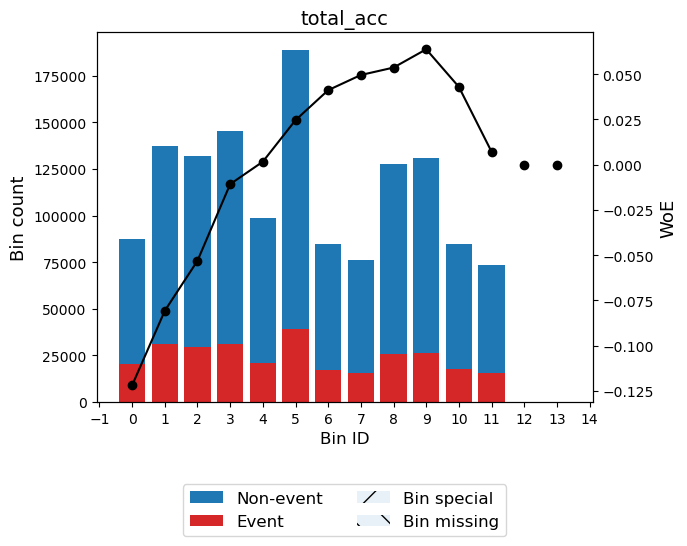

In [187]:
optb.binning_table.plot(metric="woe")

initial_list_status

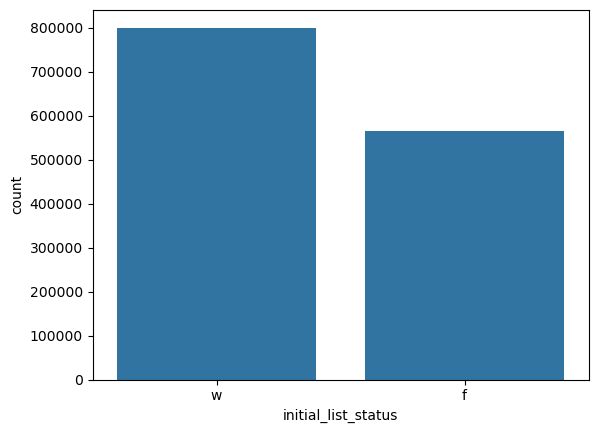

In [188]:
_ = sns.countplot(data=accepted, x="initial_list_status")

In [197]:
ct = pd.crosstab(accepted["initial_list_status"], accepted["default"])
ct

default,0,1
initial_list_status,,
f,451181,115501
w,625570,175326


In [193]:
pd.crosstab(accepted["initial_list_status"], accepted["default"], normalize="index")


default,0,1
initial_list_status,,
f,0.796,0.204
w,0.781,0.219


In [191]:
stats.pearson_chi2(accepted, "default", selected_columns=["initial_list_status"])

,feature,statistic,pvalue
0,initial_list_status,451.394,0.000


In [198]:
association(ct, method="cramer")

0.01816958803517199

In [218]:
optb = OptimalBinning(name="initial_list_status", dtype="categorical", solver="cp")
optb.fit(x=accepted["initial_list_status"], y=accepted["default"])
optb.binning_table.build()

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,[f],566682,0.414,451181,115501,0.204,0.054,0.001,0.000
1,[w],800896,0.586,625570,175326,0.219,-0.037,0.001,0.000
2,Special,0,0.000,0,0,0.000,0.000,0.000,0.000
3,Missing,0,0.000,0,0,0.000,0.000,0.000,0.000
Totals,,1367578,1.000,1076751,290827,0.213,,0.002,0.000


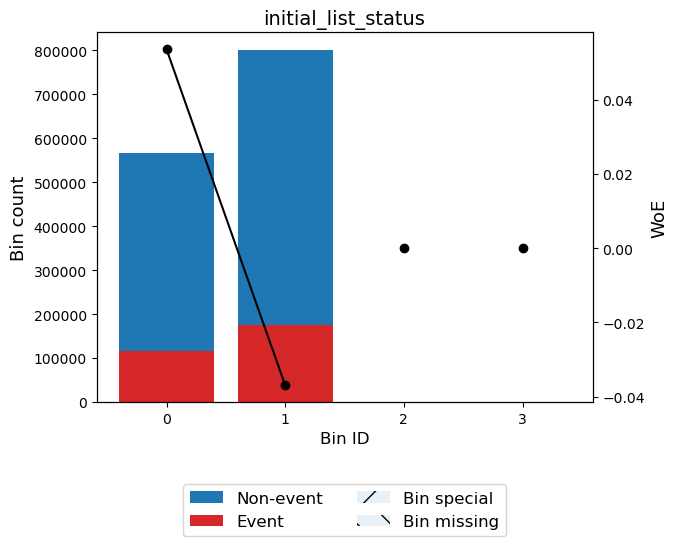

In [219]:
optb.binning_table.plot(metric="woe")

Grade is baseline. Transform/combine funded_amt, installment, fico_range_low/fico_range_high. Drop emp_length, purpose, addr_state, open_acc, pub_rec, revol_bal, revol_util, total_acc, initial_list_status

In [220]:
baseline = accepted[["grade", "default"]].copy()

In [ ]:
accepted = accepted.drop(columns=['emp_length', 
                                  'purpose', 
                                  'addr_state', 
                                  'open_acc', 
                                  'pub_rec', 
                                  'revol_bal', 
                                  'revol_util', 
                                  'total_acc', 
                                  'initial_list_status',
                                  'grade',
                                  'funded_amnt_inv',
                                  'funded_amnt'])

In [222]:
accepted["fico"] = (accepted["fico_range_high"] + accepted["fico_range_low"]) / 2

In [224]:
accepted[["fico", "fico_range_low", "fico_range_high"]].head()

,fico,fico_range_low,fico_range_high
0,677.000,675.000,679.000
1,717.000,715.000,719.000
2,697.000,695.000,699.000
4,697.000,695.000,699.000
5,692.000,690.000,694.000


In [ ]:
accepted = accepted.drop(columns=["fico_range_low", "fico_range_high"])

In [229]:
accepted["carry_rate"] = accepted["installment"] * 12 / (accepted["annual_inc"] + 1)
accepted["carry_rate"].describe()

count   1367578.000
mean          1.840
std         120.883
min           0.000
25%           0.046
50%           0.072
75%           0.106
max       17602.200
Name: carry_rate, dtype: float64

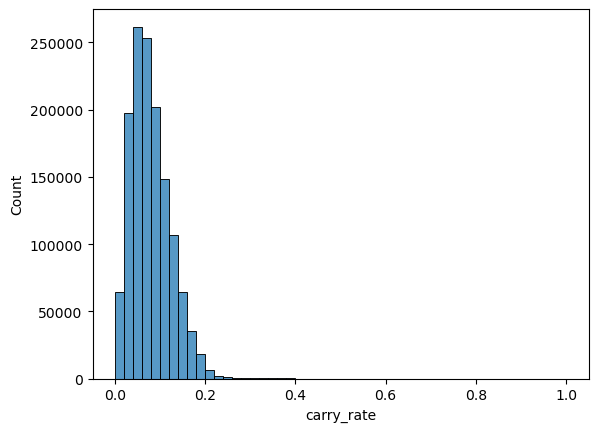

In [231]:
_ = sns.histplot(data = accepted[accepted["carry_rate"] < 1], x="carry_rate", bins=50)

In [232]:
stats.kstests(accepted, "default", selected_columns=["carry_rate"])

,feature,statistic,pvalue
0,carry_rate,0.130,0.000
